# 리포트 8-2 — 기준채널이 현실이면 **얼마를 잃는가**

이 편은 [리포트 8 «처리 사슬»](08_detector.ipynb) 의 **별편**이다 — 8 권의 사슬을 한 줄도 안 고치고 기준신호 가정 하나만 푼다. 분권이 아니다.

> **절벽은 기준채널 잡음 축에 있고, 다중경로 축은 평지다. 그리고 그 대가는 전부 ECA 단이 문다.**

패시브 레이더는 채널을 두 개 쓴다 — 조명원을 곧바로 받는 **기준채널**과 표적 에코를 받는 **감시채널**이다. 기준채널은 «수신해서 재는 신호» 이므로 잡음도 다중경로도 섞인다. 그런데 8 권의 사슬과 우리 헤드라인 검출 수치는 기준신호로 **송신 파형 그 자체**를 넣는다 — 잡음 0 · 다중경로 0, 즉 «기준안테나가 완벽하다» 는 상한이다. 이 편은 그 가정 하나만 푼다.

질문은 원장이 스스로 적어 둔 그대로다 — **«기준채널이 현실적이면(잡음·다중경로) 패시브 검출은 얼마를 잃는가»**

| 무엇 | 값 |
|---|---|
| 조명원 | **W1** WiFi VHT-LTF 76.6 MHz · **L1** LTE CRS 18.0 MHz · **G1** 5G NR SSB 7.2 MHz |
| 기하 | 챔버 바이스태틱 · β 47.6° · R_b 22.28 m · τ 74.3 ns |
| 직접파/표적비 DTR | **65.9 dB** (σ -27.58 dBsm · 감시안테나 **등방** 가정 = 최악값) |
| 사슬 | `src/passive_process.py — make_cpi · ECACanceller · range_doppler · ca_cfar_2d (읽기전용, 재구현 없음)` |
| 단일축 | 기준채널 SNR ρ_ref 0~40 dB · 다중경로비 MDR -30~-10 dB |
| 계산 | 44 분 · irsgpu1 · 2026-08-10T15:51 |

⭐ **한 줄 요약 넷**

1. **절벽은 잡음 축에 있다.** ρ_ref 를 30 → 20 dB 로 한 칸 내리면 `W1`(WiFi VHT-LTF) 의 손실이 **7.0 → 25.4 dB**, 검출률 Pd 가 **1.00 → 0.00** 로 무너진다.
2. **다중경로 축은 평지다.** MDR -30~-10 dB 어디서도 손실이 **0.54 dB** 를 넘지 않는다(세 파형 전부). 기준채널에서 무서운 것은 «반사가 섞이는 것» 이 아니라 «잡음이 섞이는 것» 이다.
3. **ρ_ref 는 우리가 고르는 값이 아니다.** ρ_ref[dB] = DTR − G_proc + SINR_target 이라는 닫힌 꼴이 성립하고, 그것을 뒤집으면 손실 3 dB 를 지키는 데 필요한 **기준안테나 이득 14.1 dB**(`W1` 기준)가 나온다. 이 편이 실측 설계로 넘어가는 다리가 그것이다. ⚠ 이 이득은 «기준안테나와 감시안테나가 똑같다» 는 **퇴화된 기준점**에서 잰 차이지 절대 사양이 아니다(절 3).
4. **대가는 전부 ECA 단이 문다.** 정합필터만 오염시키면 손실이 -0.4~+0.7 dB(사실상 0)이고, ECA 만 오염시키면 전체 손실이 거의 그대로 나온다. 반면 ECA **노치 자체**의 순수 대가는 **0.60 dB** 로 싸다.

⚠ 이 편의 검출 수치는 **한 기하 · 한 σ · 한 CPI** 에서 잰 것이다. 절대 거리나 순위는 10 권이 말하고, 여기서 말하는 것은 **이상적 기준 대비 손실**뿐이다.

⚠ **`G1`(5G SSB) 은 이 편에서 성한 물건이 아니다 — 표를 읽기 전에 알아야 한다.** ① 잡음을 0 으로 보내도 출력 SINR 이 **12.0 dB** 를 못 넘는 천장에 눌려 있어 이상 팔조차 Pd 가 0.69 다(`W1`·`L1` 은 1.00). ② 경험 Pfa 가 0.0e+00~3.3e-05 로 목표 1e-04 보다 크게 아래여서 문턱이 다른 두 파형보다 보수적으로 서 있다. **아래 모든 표에서 `G1` 열은 `W1`·`L1` 과 나란히 읽으면 안 된다** — 근거는 절 2 끝, 이유는 절 6 의 2·8번 항목.


## 절 0. 무엇을 묻나 · 무엇을 안 묻나

**묻는 것 하나.** 기준채널이 이상적이지 않을 때, 같은 사슬이 같은 표적을 놓고 **이상적 기준 대비 몇 dB 를 잃는가**. 축은 둘이고 각각 **단일축**으로만 흔든다 — 기준채널 잡음(ρ_ref)과 기준채널 다중경로(MDR).

⭐ 오염되는 것은 **우리가 재는 기준신호**이지 송신기가 보내는 신호가 아니다. 그래서 감시채널의 직접파는 팔마다 **깨끗한 송신 파형 그대로** 둔다. 이 구분을 흐리면 «기준채널 품질» 축이 «조명원 품질» 축과 섞인다.

**이 편의 앞뒤**

| 어디 | 무엇을 했나 | 이 편과의 관계 |
|---|---|---|
| [6 권 5 편 «마이크로도플러 — 바이스태틱»](06_5_bistatic.ipynb) | 표적이 바이스태틱 기하에서 무엇을 되돌려주는가 | 그 편은 «2채널 처리(ECA·CAF)는 쓰지 않는다» 고 경계를 긋고, 그 다음 질문을 이 편에 넘겼다 |
| [8 권 «처리 사슬»](08_detector.ipynb) | ECA·거리도플러·CFAR 를 세우고 경험 Pfa 를 교정했다 | 그 사슬을 **한 줄도 안 고치고** 그대로 쓴다. 다른 것은 기준신호 하나뿐 |
| **이 편 (8-2)** | 기준채널이 현실이면 그 사슬이 얼마를 잃는가 | — |
| [10 권 «결과»](10_results.ipynb) | R90 과 파형 순위 | 그 수치는 «이상적 기준» 위에 서 있다. 이 편의 손실이 그 위에 얹힌다 |
| [11 권 «실측 계획»](11_measurement.ipynb) | 야외 캠페인 규약 | 절 3 의 **기준안테나 이득 요구치**가 그리로 간다 |

**안 묻는 것 — 경계선**

| 안 한 것 | 왜 |
|---|---|
| 감시채널의 다중경로 | 같은 방이면 감시채널에도 다중경로가 있어야 물리적으로 일관되지만, 그러면 축이 둘이 된다(단일축 규칙). 표적경유 유령은 원장의 `geometry.floor_ghost` 가 따로 다룬다 |
| 안테나 패턴·차폐 설계 | 여기 DTR 은 **감시안테나 등방**이라는 최악 가정이다. 실제 패시브는 패턴으로 DTR 을 깎는다 — 그 기울기만 절 2 끝의 민감도 표로 잰다 |
| sliding ECA-S | 이 편의 ECA 는 `passive_process` 의 standard(1회 최소제곱 사영)다. 저도플러 표적 보존은 ECA-S 의 장점이지 여기 것이 아니다 |
| 추적·분류기 | 이 프로젝트의 메인 태스크는 탐지다. 절 5 의 «마이크로도플러가 남는가» 는 **알아보기**에 대한 진술이지 **찾기**에 대한 진술이 아니고, 분류기를 돌려 본 적도 없다 |
| 실제 2채널 CAF 승격 | `passive_process` 에 CAF 는 있으나 이 편의 정합필터는 «기준신호 한 프레임» 템플릿을 쓴다(절 6 의 1번 항목) |


## 절 1. 시나리오와 사슬 — 무엇을 재사용했고 무엇을 새로 했나

**재사용(읽기 전용).** 사슬은 `src/passive_process.py` 의 것을 그대로 쓴다 — `make_cpi` · `ECACanceller` · `range_doppler` · `ca_cfar_2d`. 이 편은 그 파일을 **읽기만 한다.** CFAR 명목 Pfa 는 같은 파일의 교정표(`outputs/verify_cfar.json`, 8 권 절 3)를 그대로 부르고, 0-도플러 가드는 폭 3 다.

⚠ **그 교정표는 이 편과 다른 형상에서 쟀다** — 교정표는 0-도플러 마스크 **1 빈** · CPI 프레임 M **48** · 거리빈 **16/6/24**(`W1`·`L1`·`G1` 순)에서 쟀고, 이 편은 가드 폭 **3** · M **112/56/112** · 거리빈 **32** 다. 명목 Pfa 는 형상의 함수이므로, 빌려 온 문턱이 이 편의 맵 위에서 목표 경험 Pfa 를 그대로 내지는 않는다. 그 어긋남의 크기는 절 2 끝에서 팔마다 잰다.

**새로 한 것 하나.** 기준채널을 «측정된 신호» 로 만드는 팔이다.

| 팔 | 무엇을 넣나 |
|---|---|
| `ideal` | 송신 파형 그대로 — 지금의 헤드라인 가정 |
| `refSNR ρ` | + 백색잡음, 기준채널 SNR = ρ (+40, +30, +20, +10, +0 dB) |
| `MDR d` | + 지연·감쇠 복사본, 다중경로/직접파 = d (-30, -25, -20, -15, -10 dB) · 지연 19.3, 40.0, 75.0 ns · 위상은 트라이얼마다 무작위 |
| `ECAonly` / `CAFonly` | 오염된 기준신호를 **한 단에만** 준다 — 절 4 의 분해 |

**기하와 링크버짓** — 8 권·10 권과 같은 챔버 기하다.

| 무엇 | 값 |
|---|---|
| R1 (TX→표적) · R2 (표적→RX) · L (기선) | 18.75 m · 18.61 m · 15.07 m |
| 바이스태틱 거리합 R_b · 여분지연 τ | 22.28 m · 74.3 ns |
| 바이스태틱각 β · 표적 도플러 f_d | 47.60° · 63.76 Hz (속도 3 m/s 직진) |
| 표적 σ | -27.58 dBsm |
| **DTR = 4π R1²R2²/(L²σ)** | **65.9 dB** |

⚠ **DTR 65.9 dB 는 최악 가정이다.** 원장이 그 자리에 적어 둔 문장 그대로 — «DTR = 4π R1²R2²/(L²σ) — 감시안테나가 등방(직접파 억제 0 dB)이라 가정한 최악값. 실제 패시브는 안테나 패턴·차폐로 수십 dB 를 깎는다.»

**사슬의 형상** — 파형이 정한다. 전부 10 권 «결과» 의 헤드라인 규약 그대로다. ⚠ 8 권의 CFAR 교정 형상은 이것과 다르다(교정표는 0-도플러 마스크 **1 빈** · CPI 프레임 M **48** · 거리빈 **16/6/24**(`W1`·`L1`·`G1` 순)에서 쟀고, 이 편은 가드 폭 **3** · M **112/56/112** · 거리빈 **32** 다) — 그 권에서 빌려 오는 것은 명목 Pfa 값 하나뿐이다.

| 무엇 | `W1` · WiFi VHT-LTF | `L1` · LTE CRS | `G1` · 5G NR SSB |
|---|---|---|---|
| 기준신호 대역 | 76.56 MHz | 17.98 MHz | 7.20 MHz |
| 표본율 f_s | 80.00 MHz | 30.72 MHz | 122.88 MHz |
| 프레임 M × 블록 b | 112 × 9 | 56 × 1 | 112 × 1 |
| 슬로타임 PRF · T_CPI | 2137 Hz · 52.4 ms | 1000 Hz · 56.0 ms | 2000 Hz · 56.0 ms |
| 거리빈 폭 ΔR_b | 3.92 m | 16.67 m | 41.64 m |
| 거리빈 수 · ECA 탭 | 32 · 40 | 32 · 40 | 32 · 40 |
| 이상 팔 출력 SINR | 20.10 dB | 20.18 dB | 9.14 dB |
| 트라이얼 (Pd · Pfa) | 48 · 128 | 48 · 128 | 32 · 96 |
| CFAR 셀 수 (Pfa 표본) | 446,464 | 217,088 | 334,848 |

⚠ 세 파형의 σ² 는 **팔 A 의 출력 SINR 이 목표값이 되도록 파형마다 교정**된다(목표 20 dB). W1·L1 은 그 자리에 앉았고, **G1 은 못 앉았다** — 잡음을 0 으로 보내도 출력 SINR 이 **12.0 dB** 를 못 넘는 천장이 있어 목표가 8.98 dB 로 내려갔다. 그 천장의 정체는 열잡음이 아니라 **ECA 가 못 지운 직접파 잔류**다(절 6 의 2·8번 항목).


### ⭐ 갈아끼워도 사슬이 안 변했다 — 항등식 검사

표적을 «단일 도플러 톤» 에서 «마이크로도플러 원장» 으로 갈아끼우려면 `make_cpi` 의 표적항을 못 쓴다(그 항은 톤이다). 그래서 `make_cpi` 를 고치는 대신 **두 번 불러** ① 깨끗한 지연복제 g 와 ② 배경(직접파+정적 클러터)을 따로 받고, g 에 복소변조 m(t) 를 곱한다. m(t)=exp(j2πf_d t) 를 넣으면 `make_cpi` 원래 동작과 **수치적으로 같아야 한다** — 그것을 실측한다.

| 파형 | 상대오차 |
|---|---|
| `W1` · WiFi VHT-LTF | 2.62e-17 |
| `L1` · LTE CRS | 3.40e-17 |
| `G1` · 5G NR SSB | 3.46e-17 |

세 파형 모두 **3.5e-17** — 배정밀도 반올림 수준이다. 원장이 그 자리에 적어 둔 판정 그대로: «make_cpi 원본 == (make_cpi 지연복제)×exp(j2πf_d t) + (make_cpi 배경). 상대오차가 0 이면 표적변조 갈아끼우기가 make_cpi 를 안 바꾼 것이다.»

즉 이 편에서 달라지는 것은 **기준신호 하나**이고, 사슬도 표적 주입 경로도 8 권의 그것과 같은 물건이다.


## 그림 1 — 기준채널 품질 사다리

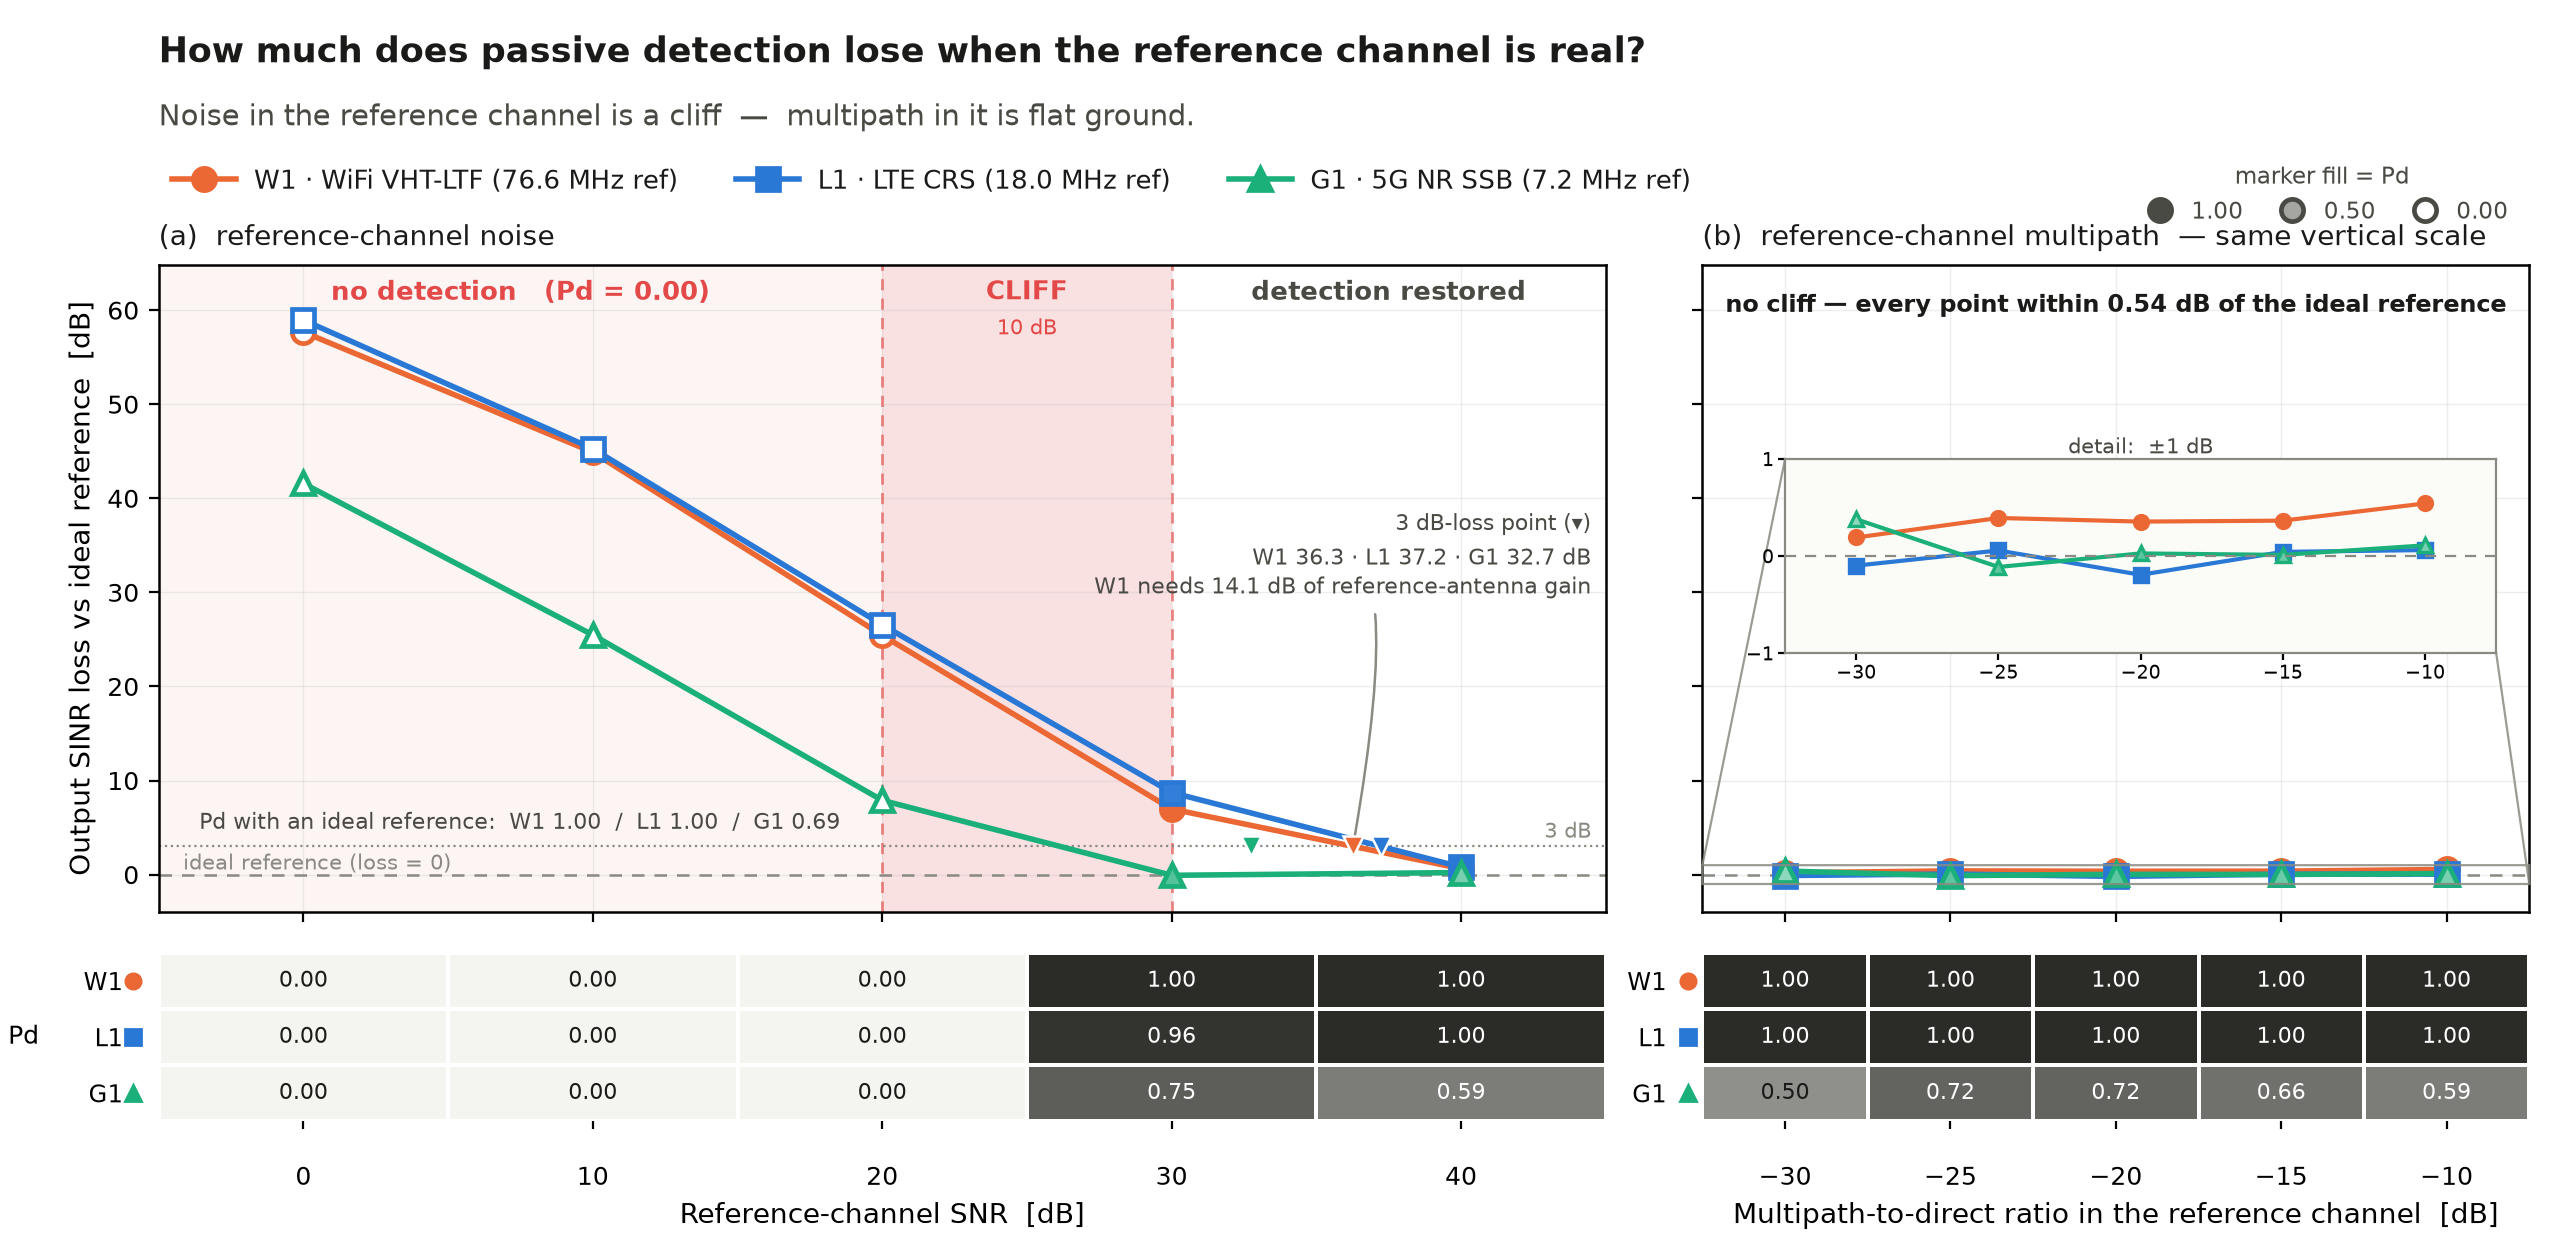

왼쪽이 기준채널 **잡음** 축, 오른쪽이 기준채널 **다중경로** 축이고 **세로 눈금이 같다**. 그 대비가 이 그림의 전부다 — 같은 자로 재면 한쪽은 벼랑이고 한쪽은 평지다. 표식 채움과 아래 띠의 숫자가 검출률 Pd 다.


## 절 2. 절벽은 SNR 축에 있고 다중경로 축은 평지다

**기준채널 잡음 — 손실 [dB] / Pd**

| ρ_ref | `W1` · WiFi VHT-LTF | `L1` · LTE CRS | `G1` · 5G NR SSB |
|---|---|---|---|
| +40 dB | 0.63 / 1.00 | 0.80 / 1.00 | 0.22 / 0.59 |
| +30 dB | 6.97 / 1.00 | 8.72 / 0.96 | -0.08 / 0.75 |
| +20 dB | 25.44 / 0.00 | 26.55 / 0.00 | 7.89 / 0.00 |
| +10 dB | 44.90 / 0.00 | 45.27 / 0.00 | 25.47 / 0.00 |
| +0 dB | 57.67 / 0.00 | 58.95 / 0.00 | 41.58 / 0.00 |

⭐ **절벽은 30 ↔ 20 dB 사이다.** 세 열이 전부 그 한 칸에서 Pd 0.5 를 가로지르지만, 그것이 «검출이 무너졌다» 와 같은 사건인 것은 `W1`·`L1` 뿐이다(바로 아래 ⚠). 그 한 칸에서 잃는 양은 `W1` 18.5 dB · `L1` 17.8 dB · `G1` 8.0 dB 다.

⚠ **`G1` 의 «가로지름» 은 이름뿐이다.** 그 열은 Pd 가 ρ 를 올려도 단조로 오르지 않고(+40 dB 에서 0.59, +30 dB 에서 0.75), 이상 팔조차 0.69 라 «Pd 0.5 를 가로지른다» 가 `W1`·`L1` 의 그 한 칸에서 보이는 1.00·0.96 → 0.00·0.00 와 같은 사건이 아니다. 절벽의 근거로는 `W1`·`L1` 만 쓴다.

**기준채널 다중경로 — 손실 [dB]**

| MDR | `W1` · WiFi VHT-LTF | `L1` · LTE CRS | `G1` · 5G NR SSB |
|---|---|---|---|
| -30 dB | +0.19 | -0.10 | +0.38 |
| -25 dB | +0.39 | +0.06 | -0.11 |
| -20 dB | +0.35 | -0.19 | +0.03 |
| -15 dB | +0.36 | +0.04 | +0.01 |
| -10 dB | +0.54 | +0.06 | +0.11 |

⭐ **평지다.** 15 칸 전부 절댓값 **0.54 dB** 안이고, 부호가 왔다 갔다 한다 — 트라이얼 산포와 같은 크기라는 뜻이다. 검출률은 `W1`·`L1` 에서 어느 칸이든 1.00 이다(`G1` 은 0.50~0.72 로 이상 팔의 0.69 주변에서 떠다닌다 — 위 경고대로 따로 읽는다).

⚠ **«평지» 는 잰 구간 안에서의 진술이다.** 다중경로 축은 -10 dB 에서 끝난다 — 반사가 직접파와 비슷한 크기까지 세지는 경우는 이 편이 **안 쟀다**. 지연도 19.3, 40.0, 75.0 ns 세 개의 단일 반사이고, 확산된 다중경로가 아니다.

⭐ **두 축을 같이 흔든 칸이 하나 있다** — `refSNR+20dB+MDR-20dB`. 잡음 위에 다중경로를 얹어도 손실이 잡음만 넣은 것과 거의 같다. 다중경로가 «잡음이 없을 때만 무해한 것» 이 아니라는 확인이다.

| 파형 | 잡음만 | 다중경로만 | 둘 다 | 둘 다 − 잡음만 |
|---|---|---|---|---|
| `W1` · WiFi VHT-LTF | 25.44 dB / Pd 0.00 | +0.35 dB / Pd 1.00 | 25.37 dB / Pd 0.00 | -0.07 dB |
| `L1` · LTE CRS | 26.55 dB / Pd 0.00 | -0.19 dB / Pd 1.00 | 26.83 dB / Pd 0.00 | +0.27 dB |
| `G1` · 5G NR SSB | 7.89 dB / Pd 0.00 | +0.03 dB / Pd 0.72 | 7.50 dB / Pd 0.00 | -0.39 dB |

**왜 한쪽만 절벽인가 — 표적이 내려간 것이 아니라 바닥이 올라온 것이다.**

같은 팔 안에서 RD 맵의 **표적 피크**와 **바닥**을 따로 재면 갈린다.

⚠ **이 표는 E1c 묶음이다 — 절 4 의 분해와 같은 팔이고, 위 사다리(E1)와는 다른 실험이다.** 팔 이름은 같지만 트라이얼이 팔당 48 → 16 으로 적고, σ² 도 따로 재교정했다(23336 → 23714, `W1` 기준). 그래서 같은 `refSNR+20dB` 라벨의 손실이 위 사다리에서 25.44 dB, 이 표에서 25.90 dB 다. 두 값이 어디서 갈리는지는 절 5 첫 표가 한 자리에 놓는다.

| 파형 | 팔 (E1c) | 피크 변화 | 바닥 변화 | 손실 (E1c) |
|---|---|---|---|---|
| `W1` · WiFi VHT-LTF | `refSNR+20dB` | -0.92 dB | **+24.98 dB** | 25.90 dB |
| `W1` · WiFi VHT-LTF | `refSNR+10dB` | +0.29 dB | **+44.11 dB** | 43.82 dB |
| `L1` · LTE CRS | `refSNR+20dB` | -0.06 dB | **+26.47 dB** | 26.54 dB |
| `L1` · LTE CRS | `refSNR+10dB` | -0.38 dB | **+45.23 dB** | 45.61 dB |
| `G1` · 5G NR SSB | `refSNR+20dB` | +0.19 dB | **+7.72 dB** | 7.53 dB |
| `G1` · 5G NR SSB | `refSNR+10dB` | +0.57 dB | **+25.88 dB** | 25.31 dB |

원장의 판정 그대로 — «표적 피크는 안 움직이고 **바닥만 올라간다** — 손실은 신호 손실이 아니라 못 지운 직접파가 만든 간섭이다.»

기준신호에 섞인 잡음은 ECA 가 푸는 최소제곱 가중치에 실려 나오고, 그 가중치로 뺀 직접파는 **덜 지워진다**. 남은 직접파가 맵 전체의 바닥을 들어 올린다. 그래서 표적 신호는 그대로인데 SINR 만 무너진다.

**ECA 소거깊이가 그 사슬을 그대로 보여준다** — 이 표는 다시 **E1 사다리**다(위 피크·바닥 표만 E1c 다).

| ρ_ref (E1) | `W1` · WiFi VHT-LTF | `L1` · LTE CRS | `G1` · 5G NR SSB |
|---|---|---|---|
| `ideal` | 79.4 dB | 79.6 dB | 76.9 dB |
| `refSNR+40dB` | 73.6 dB | 74.2 dB | 75.0 dB |
| `refSNR+30dB` | 59.2 dB | 59.2 dB | 63.5 dB |
| `refSNR+20dB` | 40.0 dB | 40.3 dB | 47.5 dB |
| `refSNR+10dB` | 20.9 dB | 21.7 dB | 30.9 dB |
| `refSNR+0dB` | 6.1 dB | 7.1 dB | 15.7 dB |

⚠ **G1 은 이 표에서 다른 물건이다.** 이상 팔에서도 Pd 가 0.69 이고(W1·L1 은 1.00), 손실이 ρ 를 내려도 W1·L1 만큼 안 오른다. 이유는 G1 의 팔 A 바닥이 이미 열잡음이 아니라 직접파 잔류이기 때문이다(천장 12.0 dB). 절 3 의 경험식이 G1 에서 깨지는 것도 같은 이유다.

⚠ **팔 간 Pd 비교는 «같은 경험적 Pfa» 가 아니다 — 어긋남은 오염 이전부터 있다.** 명목 Pfa 는 별도 교정표(`outputs/verify_cfar.json`)에서 빌려 온 값이고, **오염 이전에 형상부터 다르다** — 교정표는 0-도플러 마스크 **1 빈** · CPI 프레임 M **48** · 거리빈 **16/6/24**(`W1`·`L1`·`G1` 순)에서 쟀고, 이 편은 가드 폭 **3** · M **112/56/112** · 거리빈 **32** 다(절 1). 그래서 오염이 0 인 `ideal` 팔에서도 경험 Pfa 가 목표(1e-04)의 `W1` 0.63 · `L1` 0.55 · `G1` 0.09 배다. 기준채널이 오염되면 RD 맵의 통계가 거기서 더 움직여 교정이 더는 성립하지 않는다. 그래서 팔마다 경험 Pfa 를 같이 쟀다(절 6 의 3번 항목).

· `W1`·`L1` 은 **이 사다리의** 팔 전체가 **1.8e-05 ~ 9.4e-05**, 즉 목표의 0.18~0.94 배다. 같은 자릿수 안이라 이 두 파형끼리는 Pd 를 나란히 읽는다 — 다만 «똑같은 Pfa 에서 잰 Pd» 는 아니다.

· ⚠ `G1` 은 **0.0e+00 ~ 3.3e-05** 로 목표보다 크게 아래이고, 한 팔은 오검출이 아예 0 건이다(`refSNR+0dB`, 셀 334,848 개). 문턱이 그만큼 보수적으로 서 있다는 뜻이므로 **`G1` 의 Pd 는 다른 두 파형과 나란히 읽으면 안 된다.** 오검출이 0 건이면 그 팔의 Pfa 는 «측정된 값» 이 아니라 «96 트라이얼로는 못 잰 값» 이다.

⚠ 위 두 범위는 **이 사다리(E1)** 의 것이다. 절 4·절 5 의 팔까지 넣으면 `W1`·`L1` 의 경험 Pfa 가 **1.8e-05 ~ 1.3e-04**(목표의 0.18~1.34 배)로 벌어진다 — 그 팔들은 트라이얼이 적어 추정 자체가 성기다(부록의 트라이얼 표).


### DTR 을 깎으면 절벽이 어디로 가나

헤드라인 DTR 은 감시안테나가 등방이라는 최악값이다. 안테나 패턴·차폐로 DTR 을 깎으면 같은 ρ_ref 에서 손실이 어떻게 되는지, ρ_ref = 20 dB 한 칸에서 잰다.

| DTR | `W1` · WiFi VHT-LTF | `L1` · LTE CRS | `G1` · 5G NR SSB |
|---|---|---|---|
| 40 dB | 2.95 dB / Pd 1.00 | 3.28 dB / Pd 1.00 | -0.13 dB / Pd 0.67 |
| 50 dB | 9.92 dB / Pd 0.69 | 11.07 dB / Pd 0.00 | 0.39 dB / Pd 0.25 |
| 60 dB | 19.69 dB / Pd 0.00 | 20.63 dB / Pd 0.00 | 3.54 dB / Pd 0.00 |
| **65.9 dB (헤드라인)** | **25.44 dB / Pd 0.00** | **26.55 dB / Pd 0.00** | **7.89 dB / Pd 0.00** |

⭐ **DTR 은 둘째 손잡이다 — 다만 «dB 대 dB» 는 격자 위쪽에서만이다.** 이 표는 **DTR 40·50·60 dB 3 칸 × ρ_ref 20 dB 한 칸**을 팔당 16 트라이얼로 잰 것이다. `W1` 에서 DTR 을 60 → 40 dB 로 20 dB 깎으면 손실이 19.7 → 2.9 dB 로 내려간다. 그러나 **기울기는 칸마다 다르다** — 60→50 dB 에서 `W1` 0.98 · `L1` 0.96 dB/dB · 50→40 dB 에서 `W1` 0.70 · `L1` 0.78 dB/dB 다. 아래쪽 칸에서 꺾이는 것은 잡음이 아니라 **경험식의 무릎**이다 — 이 격자의 아래끝 DTR 40 dB 가 정확히 2ρ_ref = 40 dB 라 거기서 곡선이 3.01 dB 로 눕는다. ⛔ 그러므로 «DTR 을 1 dB 깎으면 손실 1 dB 를 돌려받는다» 는 **DTR ≫ 2ρ_ref 인 쪽에서만** 읽는다. DTR 40 dB 아래는 **안 쟀다** — 더 깎아서 남은 3.01 dB 보다 더 벌 수 있는지는 이 편이 모른다. `G1` 행은 기울기가 0.32·0.05 dB/dB 로 아예 다른 물건이다(천장 12.0 dB). 이 표에서 확실한 것은 하나다 — 이 편의 손실 수치는 «기준채널이 나쁘다» 만의 함수가 아니라 **감시안테나가 직접파를 얼마나 죽였는가**의 함수이기도 하고, 실측 설계에서 두 손잡이는 **독립**이다.

⚠ **«검출이 되살아난다» 도 3 칸짜리 진술이다.** `W1` 의 Pd 는 DTR 60 dB 0.00 → 50 dB 0.69 → 40 dB 1.00 인데 팔당 16 트라이얼이라 Pd 눈금 자체가 0.06 다. Pd 가 0.5 를 가로지르는 자리는 **DTR 10 dB 폭 한 칸 안**으로만 안다 — 그 안 어디인지는 안 쟀다.

⚠ **이 표는 절 3 의 설계 규칙(ρ_ref ≥ DTR/2)을 «확인» 하지 못한다 — 그 자리는 경험식의 등호 자리라 값이 정의상 나온다.** ρ_ref 가 DTR/2 면 식의 지수가 정확히 0 이라 loss = 10log₁₀(1+10⁰) = **3.01 dB** 이고, 설계 규칙은 그 등호를 «손실 ≤ 3 dB ⟺ ρ_ref ≥ DTR/2» 로 옮겨 적은 것이다. DTR 40 dB 칸(ρ_ref = 20 dB 가 정확히 DTR/2 인 자리)에서 «3 dB 가 나왔다» 는 그래서 규칙의 검증이 아니다.

이 칸이 실제로 재는 것은 하나다 — **ρ 축에서 맞춘 식이 DTR 축에서도 같은 DTR − 2ρ_ref 꼴로 움직이는가.** 잰 값과 식의 차이는 `W1` -0.35/-0.49/-0.06 · `L1` +0.59/+0.65/+0.27 dB(DTR 60/50/40 dB 순), 즉 3 칸 전부 절댓값 0.65 dB 안이다. ⛔ 다만 그 차이는 같은 식이 ρ 축에서 이미 내는 평균절대오차 **0.72 dB** 보다 작다 — 이 격자로는 규칙의 3 dB 를 그 오차보다 좁게 못 박는다. 그리고 이것은 **ρ_ref 한 칸 · DTR 3 칸 · 팔당 16 트라이얼 · `W1`·`L1` 두 파형**의 진술이다. 같은 3 칸에서 `G1` 의 차이는 -16.50/-10.03/-3.15 dB 라 규칙이 거기까지 가지 않는다.

⚠ **왜 2ρ_ref 인지는 모른다.** 원장이 그 자리에 적어 둔 그대로 — 이 식은 유도된 것이 아니라 **맞춰 본** 것이고, 1차 이론 추정(잔류 = dpi²σ_n²)은 이 기울기를 재현하지 못한다(절 3 의 적용범위 문장). 그러므로 «ρ_ref ≥ DTR/2» 는 **잰 격자 안에서 성립한 경험 규칙**이지 물리에서 나온 문턱이 아니다.


## 절 3. ⭐ ρ 는 자유 파라미터가 아니다

절 2 의 사다리는 ρ_ref 를 **가정**해 훑은 것이다. 그런데 같은 링크버짓 안에서는 ρ_ref 가 계산된다 — 기준안테나가 받는 것은 감시안테나가 지우려는 바로 그 직접파이고, 잡음은 같은 수신기의 잡음이다.

$$\rho_{ref}[\mathrm{dB}] \;=\; \mathrm{DTR} \;-\; G_{proc} \;+\; \mathrm{SINR}_{target}$$

원장이 그 자리에 적어 둔 문장 그대로 — «ρ_ref[dB] = DTR − G_proc + SINR_target — ρ 는 자유 파라미터가 아니다»

| 파형 | DTR | 처리이득 G_proc | 이상 팔 SINR | ⇒ 자기일관 ρ_ref | 그 자리의 손실 / Pd |
|---|---|---|---|---|---|
| `W1` · WiFi VHT-LTF | 65.9 dB | 63.78 dB | 20.10 dB | **22.18 dB** | 21.41 dB / 0.22 |
| `L1` · LTE CRS | 65.9 dB | 58.92 dB | 20.18 dB | **27.12 dB** | 13.86 dB / 0.68 |
| `G1` · 5G NR SSB | 65.9 dB | 61.01 dB | 9.14 dB | **13.98 dB** | 18.47 dB / 0.00 |

⚠ 이 ρ_ref 는 **«안테나로 아무것도 안 했을 때» 의 점**이지 예측이 아니다. 원장의 단서 그대로 — «ρ_ref = DTR − 10log10(σ²) — **기준안테나와 감시안테나가 똑같다**는 퇴화된 경우의 값이다. 실제 패시브는 안테나가 둘이고 손잡이도 둘이다: DTR 은 **감시안테나가 조명원을 얼마나 죽이나**, ρ_ref 는 **기준안테나가 조명원을 얼마나 잘 받나**. 둘은 독립이다. 이 값은 «안테나로 아무것도 안 했을 때» 우리가 어디에 서 있는지를 표시하는 점이지 예측이 아니다.»

⚠ **오른쪽 두 칸은 사다리 두 칸 사이의 선형 보간이다.** 자기일관 ρ_ref 가 스윕 격자 위에 앉지 않아서다. 특히 Pd 는 그 구간이 바로 절 2 의 **절벽**이라(30 dB 에서 1.00, 20 dB 에서 0.00) 그 보간값(0.22)은 **측정된 검출률이 아니다** — «절벽 안쪽» 이라는 위치 표시로만 읽어야 한다.

**그래서 뒤집어 읽는다 — 3 dB 손실을 지키려면 기준채널 SNR 이 얼마여야 하나.**

| 파형 | 필요한 ρ_ref (손실 3 dB) | 지금 서 있는 자리 | ⇒ **기준안테나 이득 요구치** |
|---|---|---|---|
| `W1` · WiFi VHT-LTF | 36.27 dB | 22.18 dB | **14.09 dB** |
| `L1` · LTE CRS | 37.22 dB | 27.12 dB | **10.10 dB** |
| `G1` · 5G NR SSB | 32.75 dB ⚠ 비단조 보간 | 13.98 dB | **18.77 dB** |

⚠ **`G1` 행은 비단조 곡선의 보간값이다.** `G1` 의 3 dB 교차점은 손실을 오름차순으로 세운 뒤 보간해 얻으므로 ρ_ref 40 dB(손실 +0.22 dB)와 20 dB(+7.89 dB) 사이에서 **32.75 dB** 가 나오고, 그 사이의 ρ_ref 30 dB 칸(손실 -0.08 dB)은 건너뛴다. 절 2 사다리의 그 칸과 이 값은 같은 곡선을 두 방향으로 읽은 결과이고, 한 점에서 만나지 않는다.

⭐ **이것이 이 편에서 실측 설계로 넘어가는 다리다.** `W1`·`L1` 의 요구치가 10.1~14.1 dB 이므로, 기준안테나는 조명원 방향으로 그만큼의 이득을 **감시안테나보다 더** 가져야 한다. «패시브 수신기를 두 개 만든다» 는 설계 결정이 여기서 숫자로 나온다.

⚠ 이 «요구치» 는 절대 사양이 아니라 **바로 위 표의 자기일관 ρ_ref 를 기준선으로 뺀 차이**다. 그 기준선이 퇴화된 점이므로(바로 위 ⚠), 읽는 법은 «기준안테나가 이만큼의 이득을 내야 한다» 가 아니라 «안테나로 아무것도 안 한 자리에서 이만큼을 더 벌어야 한다» 다. 실제 프론트엔드가 그것을 내는지는 11 권이 닫는다.

⚠ 세 요구치 중 **`G1` 의 값은 다른 뜻이다** — `G1` 은 손실 곡선 자체가 천장에 눌려 있어 «3 dB 손실» 이라는 기준이 `W1`·`L1` 과 같은 물건이 아니고, 그 눌림이 곡선을 비단조로 만들어 교차점이 위 ⚠ 의 보간으로 잡힌다. 설계 근거로는 `W1`·`L1` 의 10.1~14.1 dB 를 쓴다.

**⭐ 스윕에서 읽어낸 경험식**

$$\text{loss}[\mathrm{dB}] \;=\; 10\log_{10}\!\left(1 + 10^{(\mathrm{DTR} - 2\rho_{ref})/10}\right)$$

같은 것을 다르게 쓰면 — «loss_dB ≈ max(0, DTR_dB − ECA_depth_dB),  ECA_depth_dB ≈ 2·ρ_ref_dB (이상 깊이에서 포화)» 이고, 설계 규칙으로 옮기면 «손실 ≤ 3 dB ⟺ ρ_ref ≥ DTR/2» 이다.

| 파형 | ρ_ref | 실측 손실 | 식이 주는 값 | 잔차 |
|---|---|---|---|---|
| `W1` · WiFi VHT-LTF | 40 dB | 0.63 dB | 0.16 dB | +0.47 dB |
| `W1` · WiFi VHT-LTF | 30 dB | 6.97 dB | 6.86 dB | +0.11 dB |
| `W1` · WiFi VHT-LTF | 20 dB | 25.44 dB | 25.87 dB | -0.43 dB |
| `W1` · WiFi VHT-LTF | 10 dB | 44.90 dB | 45.86 dB | -0.96 dB |
| `L1` · LTE CRS | 40 dB | 0.80 dB | 0.16 dB | +0.64 dB |
| `L1` · LTE CRS | 30 dB | 8.72 dB | 6.86 dB | +1.86 dB |
| `L1` · LTE CRS | 20 dB | 26.55 dB | 25.87 dB | +0.68 dB |
| `L1` · LTE CRS | 10 dB | 45.27 dB | 45.86 dB | -0.59 dB |
| `G1` · 5G NR SSB | 40 dB | 0.22 dB | 0.16 dB | +0.05 dB |
| `G1` · 5G NR SSB | 30 dB | -0.08 dB | 6.86 dB | -6.94 dB |
| `G1` · 5G NR SSB | 20 dB | 7.89 dB | 25.87 dB | -17.98 dB |
| `G1` · 5G NR SSB | 10 dB | 25.47 dB | 45.86 dB | -20.39 dB |

W1·L1 은 평균절대오차 **0.72 dB** 로 맞는다. **G1 은 안 맞는다 — 11.3 dB** 다.

⚠ 원장이 스스로 적어 둔 적용범위 그대로 — «ρ_ref 10~40 dB, DTR 40~66 dB 에서 W1·L1 은 평균절대오차 <1 dB 로 맞는다. ⚠ **G1(5G SSB)에는 안 맞는다**(오차 최대 20 dB) — G1 은 팔 A 의 바닥이 이미 열잡음이 아니라 직접파 잔류라 «잔류를 얹는다» 는 전제가 깨지기 때문이다. 유도된 식이 아니라 **맞춰본 식**이다 — 1차 이론 추정(잔류=dpi²σ_n²)은 이 기울기를 재현하지 못한다(왜 2ρ 인지 아직 모른다).»


## 그림 2 — 어느 단이 대가를 무나

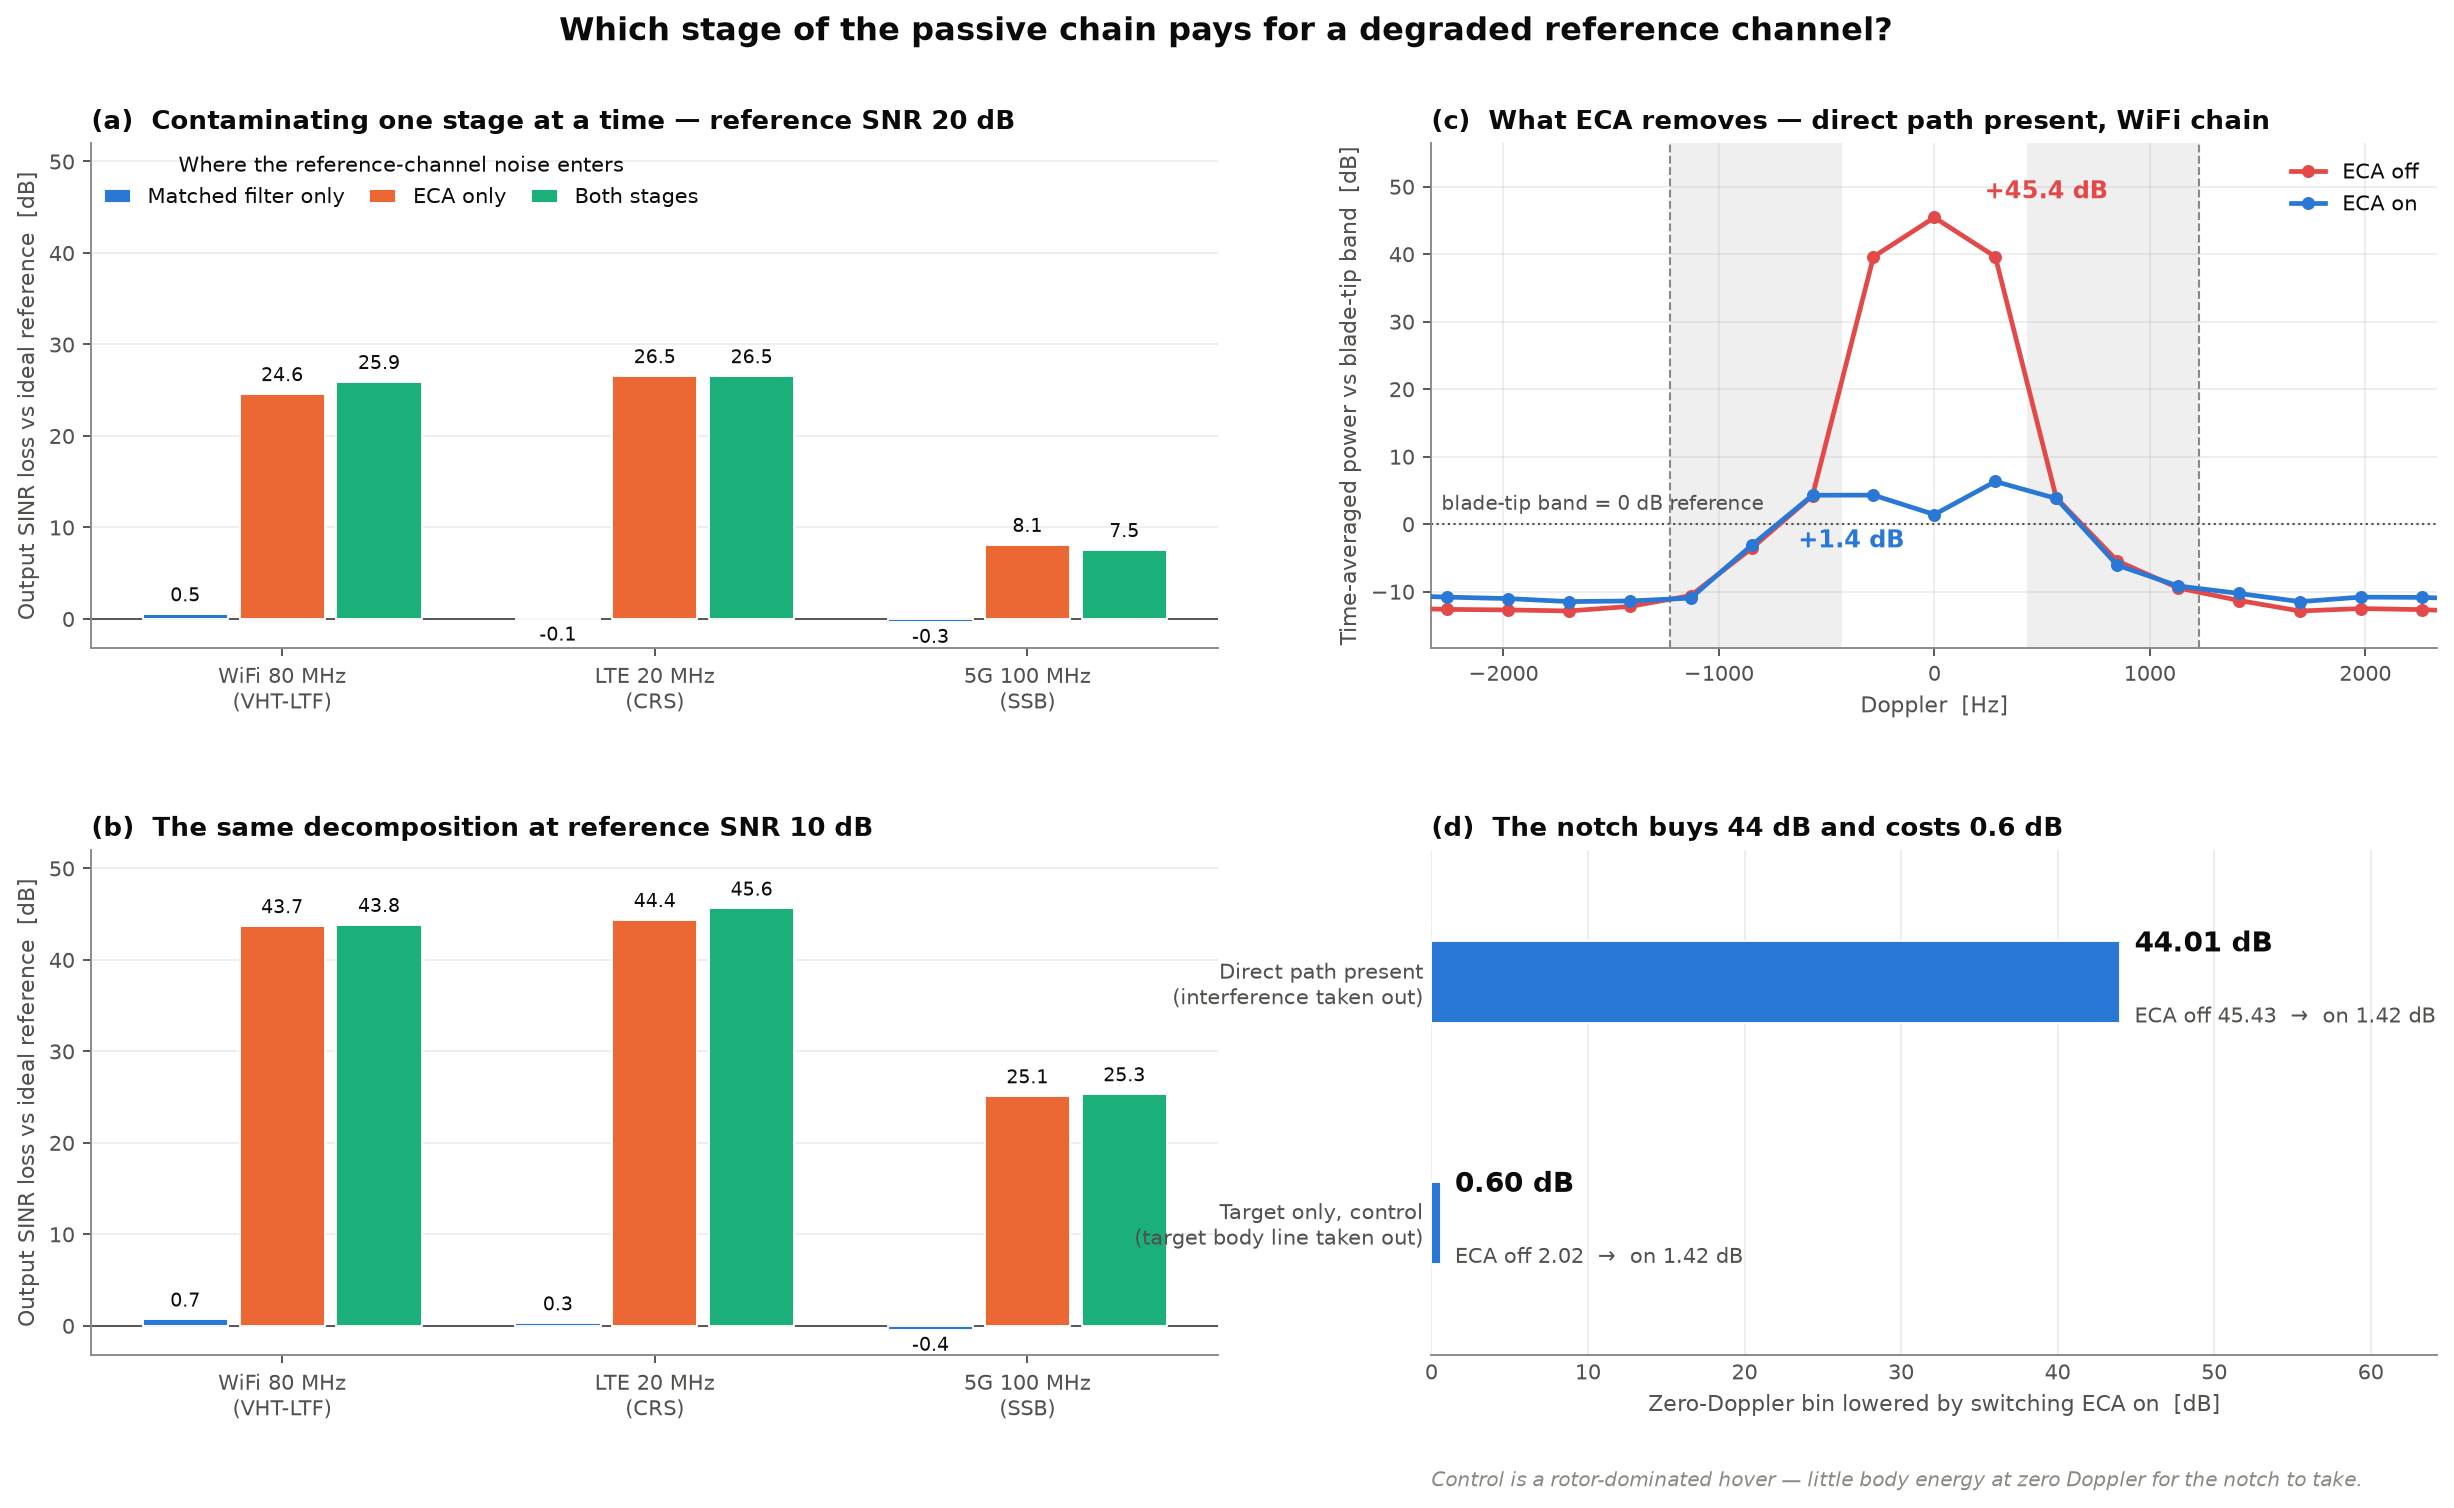

(a)(b) 가 오염을 **한 단에만** 넣은 분해이고, (c)(d) 가 ECA 노치의 값과 대가다. (c) 의 세로축 0 dB 는 날개끝 띠이고, (d) 의 대조군은 직접파를 끈 **표적만 있는** 형상이다 — 그래야 노치가 «무엇을 걷어냈나» 가 아니라 «표적에서 무엇을 뺏었나» 를 잰다.


## 절 4. 손실은 전부 ECA 단에서 나온다 — 그리고 노치 자체는 싸다

오염된 기준신호를 **정합필터에만** 준 팔, **ECA 에만** 준 팔, 둘 다 준 팔을 나란히 돌린다.

⚠ 이 분해는 **E1c 묶음**이다 — 절 2 의 피크·바닥 표와 같은 팔이고, 절 2 사다리(E1)와는 트라이얼(팔당 16 대 48)도 σ² 교정도 다른 실험이다(절 5 첫 표).

| 파형 | 오염 수준 | 정합필터만 | ECA 만 | 둘 다 |
|---|---|---|---|---|
| `W1` · WiFi VHT-LTF | ρ_ref +20 dB | **+0.51 dB** | 24.58 dB | 25.90 dB |
| `W1` · WiFi VHT-LTF | ρ_ref +10 dB | **+0.68 dB** | 43.69 dB | 43.82 dB |
| `L1` · LTE CRS | ρ_ref +20 dB | **-0.07 dB** | 26.54 dB | 26.54 dB |
| `L1` · LTE CRS | ρ_ref +10 dB | **+0.27 dB** | 44.36 dB | 45.61 dB |
| `G1` · 5G NR SSB | ρ_ref +20 dB | **-0.32 dB** | 8.09 dB | 7.53 dB |
| `G1` · 5G NR SSB | ρ_ref +10 dB | **-0.43 dB** | 25.09 dB | 25.31 dB |

⭐ **판정: 전부 ECA 단이다.** 정합필터만 오염시키면 손실이 -0.43~+0.68 dB 이고 검출률도 안 떨어진다(`CAFonly-noisy+20dB` 의 Pd `W1` 1.00 · `L1` 1.00 · `G1` 0.81). ECA 만 오염시키면 둘 다 오염시킨 것과 거의 같은 손실이 나온다.

**왜 ECA 만 아픈가.** 정합필터는 기준신호를 **상관기의 템플릿**으로 쓴다 — 템플릿에 잡음이 섞이면 정합이 조금 나빠질 뿐이고, 그 대가는 상관이득 안에서 평균된다. ECA 는 기준신호로 **XᴴX 를 풀어 감시채널에서 뺄 것을 만든다** — 그 역행렬이 잡음을 증폭하고, 잘못 만든 뺄셈은 직접파를 남긴다. 남은 직접파는 평균되지 않고 맵 전체의 바닥이 된다(절 2 의 피크/바닥 표).

그 민감도는 기준신호의 조건수로 갈린다.

| 파형 | ECA 행렬 조건수 |
|---|---|
| `W1` · WiFi VHT-LTF | 9.4 dB |
| `L1` · LTE CRS | 38.3 dB |
| `G1` · 5G NR SSB | 50.4 dB |

⚠ 조건수가 가장 나쁜 것은 대역이 가장 좁은 `G1`(50.4 dB)이고, 그것이 G1 의 «천장» 과 같은 뿌리다 — 7.2 MHz 기준신호를 122.88 MHz 로 표본화한 채 ECA 를 풀면 행렬이 준특이라 직접파가 안 지워진다.

**⭐ 그런데 노치 자체는 싸다.**

| 무엇 | 값 |
|---|---|
| ECA 를 끄면 0-도플러가 날개끝 띠 대비 | **+45.4 dB** |
| ECA 를 켜면 | +1.4 dB |
| ⇒ 직접파가 있을 때 노치가 버는 값 | 44.01 dB |
| **표적만 있는 대조군에서 노치가 무는 대가** | **0.60 dB** |

원장의 정의 그대로 — «표적만 있는 대조군에서 ECA 를 켜고 끈 차이 — 0-도플러 한 빈(동체선)이 날개끝 띠 대비 몇 dB 내려가나. 이것이 ECA 노치의 순수한 대가다.»

즉 «ECA 가 0-도플러를 파먹어 동체선을 잃는다» 는 걱정은 이 형상에서 값이 0.60 dB 이고, 같은 노치가 직접파가 있을 때 44 dB 를 번다. ⚠ 이 대조군은 **로터가 지배하는 호버**라 0-도플러에 노치가 가져갈 동체 에너지가 애초에 적다 — 기동 중인 표적에서는 이 값이 커진다.


## 그림 3 — 마이크로도플러는 검출이 죽은 뒤에도 남는가

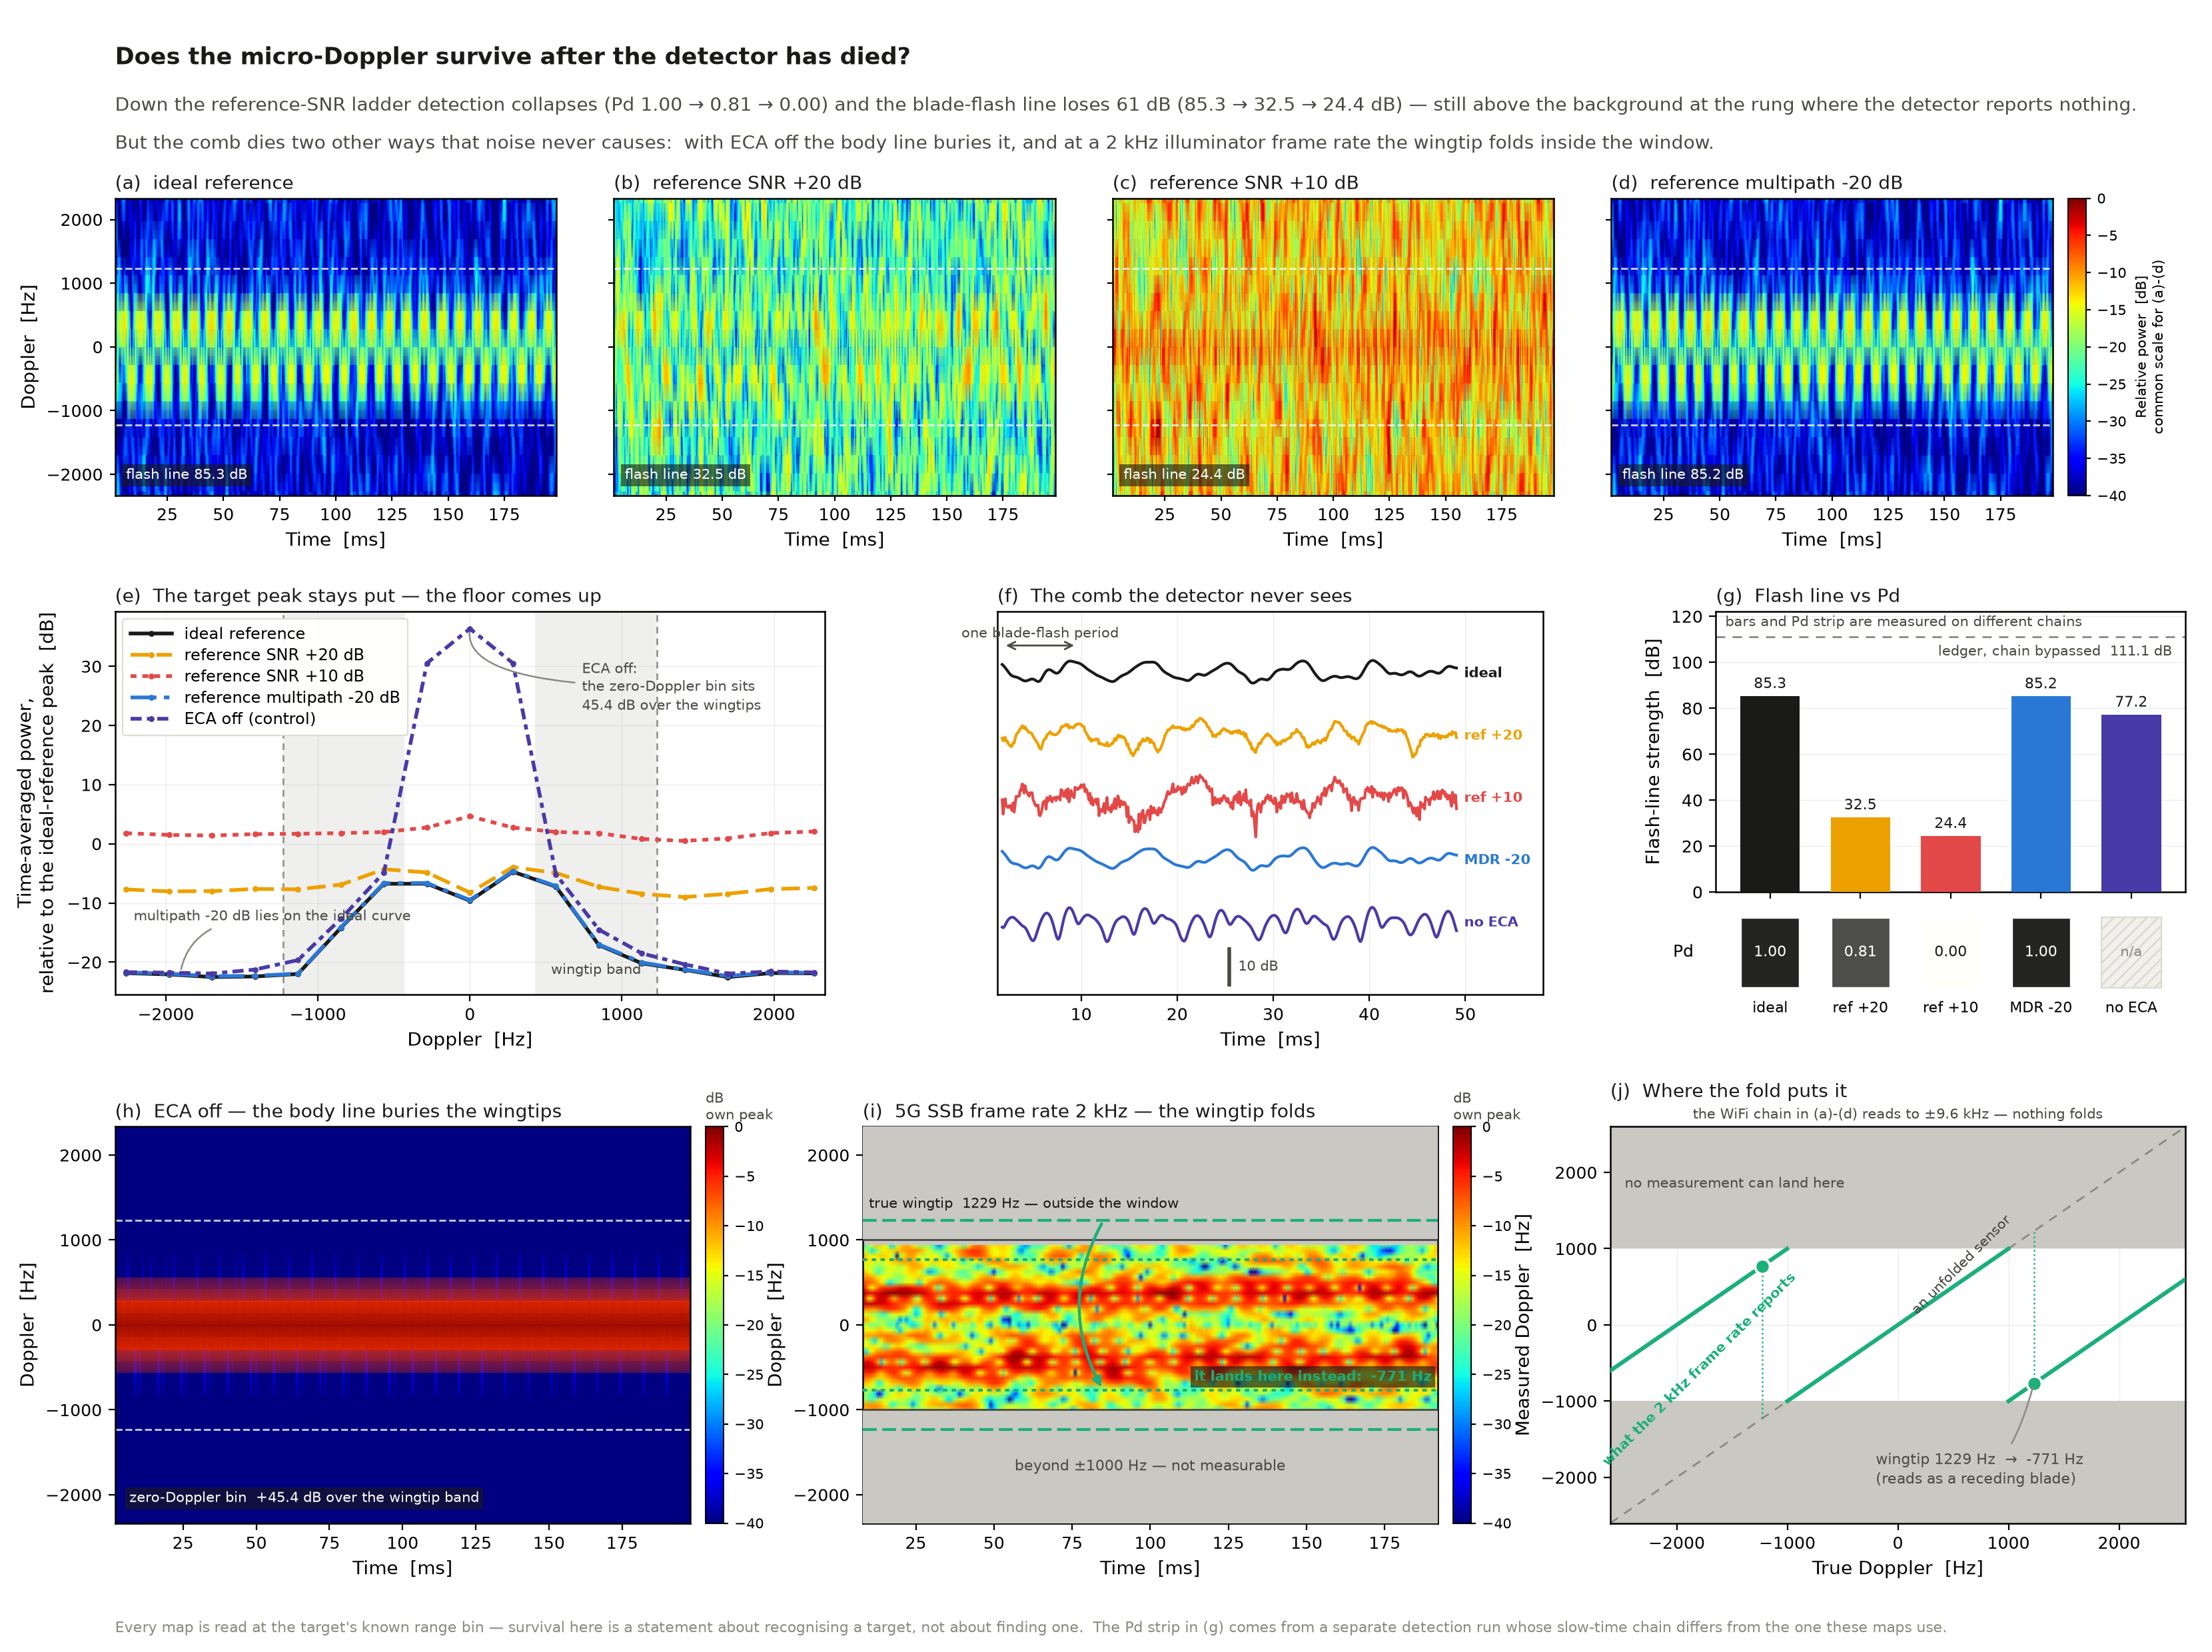

(a)~(d) 가 사다리의 시간-도플러 맵이고 **공통 눈금**이다(팔마다 자기 최대로 맞추면 «바닥이 올라온다» 가 사라진다). (e) 가 그 바닥을 절대 눈금 하나로 잰 것, (f) 가 날개끝 띠 전력의 시간축(플래시 빗살), (g) 가 플래시 선 세기와 Pd 를 나란히 놓은 것이다. (h)(i)(j) 는 **잡음이 아닌 방식으로** 빗살이 죽는 두 경우다.

⚠ (g) 의 막대(플래시)와 아래 띠(Pd)는 **다른 사슬에서 잰 값**이다 — 팔 이름만 같다. 무엇이 다른지는 절 5 첫 표에 있다.

⭐ 맵은 전부 `src/md_mapstyle.py` 규약이다 — STFT 만 쓰고(재할당·WVD 없음), jet · 0~−40 dB · gouraud · 날개끝 흰 파선. 조각 길이·hop 등 설정값은 부록에 적었다.


## 절 5. Pd 가 0 인 칸에서 빗살은 어디까지 남나 — 그리고 5G 는 접힌다

표적 거리빈에서 슬로타임을 꺼내 시간-도플러 맵을 만들고, 같은 이름의 사다리에서 **플래시가 읽히는가**를 잰다.

**먼저 지표의 뜻.** `플래시 선 세기` 는 절대 세기가 아니라 **비**다 — 날개끝 띠 전력의 시간축 스펙트럼에서 플래시 주파수 성분이 그 스펙트럼의 **배경 중앙값보다 몇 dB 솟았나**이다(정의는 `benchmark/passive_two_channel_md.py` 의 `md_metrics`). 그래서 이 값이 0 dB 로 내려오면 빗살이 배경에 묻혔다는 뜻이고, 값이 크면 «빗살이 주기적으로 서 있다» 는 뜻이다. `플래시 대비` 는 같은 띠 전력의 시간축 p95−p5 이고 **잡음 변동만으로도 커진다** — 판정값은 선 세기 쪽이다.

⚠ **여기에는 사다리가 둘이고, 둘 다 절 2 의 사다리와 같은 물건이 아니다.** 팔 이름만 같다 — 맵은 생존 사다리에서, Pd 는 그것과 또 다른 검출 사다리에서 나온다. 아래 표는 이 편이 돌린 네 묶음을 한 자리에 놓는다. 절 2 끝의 피크·바닥 표와 절 4 의 분해가 쓰는 **E1c** 도 여기 들어 있다 — 같은 `refSNR+20dB` 라벨의 손실이 25.44 dB(E1) 와 25.90 dB(E1c) 로 갈리는 자리가 이 표의 마지막 두 줄이다.

| 무엇 | 절 2 의 검출 사다리 (E1) | 절 2 끝·절 4 의 피크·바닥과 분해 (E1c) | 절 5 의 Pd 를 낸 사다리 (E1b) | 절 5 의 맵 (E2) |
|---|---|---|---|---|
| 표적 모형 | tone (단일 도플러 톤) | tone (같은 톤) | md (마이크로도플러 원장) | md (같은 원장) |
| 슬로타임 사슬 | 블록 b=9 · PRF 2137 Hz · T_CPI 52 ms | b=9 · PRF 2137 Hz · T_CPI 52 ms | b=9 · PRF 2137 Hz · T_CPI 52 ms | b=1 · PRF 19231 Hz · 관측 200 ms |
| 날개끝이 접히나 | **접힌다** (f_tip 1229 Hz > ±1068 Hz) | **접힌다** (±1068 Hz) | **접힌다** (±1068 Hz) | 안 접힌다 (±9615 Hz) |
| σ² | 23336 (목표 SINR 20 dB) | 23714 — 같은 목표 20 dB 를 이 묶음에서 **따로 재교정**했다 | 3652 — 표적이 마이크로도플러라 같은 출력 SINR 을 맞추려고 톤 실험보다 **8.1 dB 낮게** 잡혔다 | 1540 (목표 SINR 20 dB) |
| 트라이얼 (Pd · Pfa) | 48 · 128 | 16 · 32 | 16 · 32 | — |
| `refSNR+20dB` 팔의 손실 | **25.44 dB** | **25.90 dB** | 8.08 dB | — |

그래서 같은 `refSNR+20dB` 라벨인데도 Pd 가 절 2 표에서는 0.00, 여기서는 0.81 다 — 모순이 아니라 **링크버짓이 다른 두 실험**이다. ⚠ 따라서 아래 표의 «플래시» 열과 «Pd» 열은 **서로 다른 사슬에서 잰 값**이다. 나란히 놓은 것은 «같은 기준채널 품질에서 두 능력이 각각 어떻게 되나» 를 보려는 것이지 한 실험의 두 출력이 아니다.

| 팔 | 플래시 선 세기 | 플래시 대비 | 0-도플러 / 날개끝 | 같은 이름 팔의 Pd |
|---|---|---|---|---|
| `ideal` | 85.3 dB | 5.07 dB | +1.42 dB | 1.00 |
| `refSNR+20dB` | 32.5 dB | 6.50 dB | -1.92 dB | 0.81 |
| `refSNR+10dB` | 24.4 dB | 7.32 dB | +2.96 dB | 0.00 |
| `MDR-20dB` | 85.2 dB | 5.10 dB | +1.43 dB | 1.00 |
| `noECA` | 77.2 dB | 6.83 dB | +45.43 dB | — |
| `ledger_direct` (사슬 미경유) | 111.1 dB | 17.82 dB | — | — |

⭐ **Pd 가 0.00 인 칸에서도 빗살 선은 배경보다 24.4 dB 위에 있다 — 다만 여유는 그 전에 거의 다 썼다.** 플래시 선은 85.3 → 32.5 → 24.4 dB 로 모두 60.9 dB 내려가는데, 그 중 **52.8 dB 가 첫 칸에서** 빠진다. 그 첫 칸의 Pd 는 아직 0.81 다. 즉 «검출이 먼저 죽는다» 는 순서는 **마지막 한 칸에서만** 성립하고, 여유를 잃는 속도는 빗살 쪽이 훨씬 빠르다. 그리고 `refSNR+10dB` 아래 칸은 **안 쟀다** — 곡선이 어디서 0 dB 에 닿는지는 이 편이 모른다.

⚠ **이 «생존» 은 측정점 한 개다.** Pd 가 0 인 팔은 `refSNR+10dB` 하나뿐이고, 파형은 `W1` 하나뿐이며(5G 사슬의 맵은 `ideal` 팔 1 개뿐이라 사다리가 없다), 잡음 팔 자체가 2 칸뿐이다. 게다가 이 사슬은 **날개끝이 안 접히는 쪽**이고 검출 CPI 는 접히는 쪽이다. ⛔ 그러므로 이 절을 **«검출은 실패해도 분류는 된다»** 로 일반화하면 안 된다 — 분류기를 돌려 본 적이 없고, 잰 것은 «한 칸에서 빗살 선이 아직 배경 위에 있었다» 까지다.

⚠ 플래시 **대비**는 오히려 5.07 → 7.32 dB 로 **커진다**. 무늬가 또렷해진 것이 아니라 띠 전력의 변동에 잡음 변동이 얹힌 것이다 — 이 상승을 «잡음이 늘었는데 분류가 쉬워졌다» 로 읽으면 거꾸로 읽는 것이다.

⚠ 이 판정은 **표적의 거리빈을 알고 있을 때** 읽은 것이다. 즉 «찾기» 가 아니라 «알아보기» 에 대한 진술이다. 검출이 죽은 팔에서 이 맵을 얻으려면 표적 위치를 다른 수단이 알려 줘야 한다.

**빗살이 죽는 방식은 잡음 말고 둘 더 있다.**

① **ECA 를 끄면 동체선이 덮는다.** 0-도플러 한 빈이 날개끝 띠보다 **+45.4 dB** 위로 솟는다(켜면 +1.4 dB). 플래시 선 세기 자체는 77.2 dB 로 높지만, 읽히는 것은 동체선이지 블레이드가 아니다.

② ⭐ **5G 팔은 프레임률로 날개끝이 접힌다.** 이 팔이 채널을 읽는 속도는 2 kHz — 슬롯 하나를 한 프레임으로 읽는 **슬롯율**이다(원장의 이름 그대로 «5G slot rate (0.5 ms slot at 30 kHz SCS)»). 그래서 무모호 도플러가 **±1000 Hz** 뿐인데, 이 기체의 날개끝 도플러는 **1229 Hz** 다. 그 차이는 측정 잡음이 아니라 **접힘**으로 나타난다 — 참 도플러 1229 Hz 가 **-771 Hz**, 즉 «멀어지는 블레이드» 로 읽힌다.

⚠ **그 2 kHz 는 SSB 버스트율이 아니다.** 상시 기준신호로 쓸 수 있는 SSB 는 주기 20 ms, 즉 50 Hz 라 무모호 도플러가 ±25 Hz 로 훨씬 좁다(7 권 절 7). 그래서 이 팔은 5G 에 **유리한 쪽으로 낙관적**이고, 진짜 상시 SSB 로는 접힘이 더 심하다 — 원장이 그 자리에 스스로 적어 둔 단서다 ⟨outputs/passive_two_channel.json : md_survival.nr_alias.what⟩.

| 파형 | 슬로타임 PRF | 무모호 도플러 | 날개끝 f_tip | 접히나 |
|---|---|---|---|---|
| `W1` · WiFi VHT-LTF | 2137 Hz | ±1068 Hz | 1229 Hz | **접힌다** |
| `L1` · LTE CRS | 1000 Hz | ±500 Hz | 1229 Hz | **접힌다** |
| `G1` · 5G NR SSB | 2000 Hz | ±1000 Hz | 1229 Hz | **접힌다** |
| 생존 판정에 쓴 WiFi 사슬 | 19231 Hz | ±9615 Hz | 1229 Hz | 아니오 |

⚠ 표의 PRF 는 **사슬이 프레임을 끊어 읽는 속도**(검출기 프레임률)다 — `G1` 행의 2 kHz 는 5G 슬롯율이고, 상시 SSB 의 물리 반복률 50 Hz 와는 다른 양이다(바로 위 ⚠).

⚠ 검출용 CPI(첫 세 줄)는 세 파형 **모두** 접힌다 — 슬로타임 PRF 가 f_tip 의 두 배에 못 미친다. 그것이 검출 성능에 얹는 대가가 다음 표다.

**마이크로도플러가 검출에 무는 값 — 톤 표적 대비**

| 파형 | 톤 표적 RD 피크 | 마이크로도플러 표적 | 확산 손실 |
|---|---|---|---|
| `W1` · WiFi VHT-LTF | 125.66 dB | 119.93 dB | **5.73 dB** |
| `L1` · LTE CRS | 117.09 dB | 110.88 dB | **6.21 dB** |
| `G1` · 5G NR SSB | 129.59 dB | 123.37 dB | **6.22 dB** |

같은 평균전력으로 정규화한 표적을 톤에서 로터 변조로 갈아끼우면 RD 피크가 5.7~6.2 dB 내려간다 — 로터가 표적 에너지를 도플러축으로 흩는 대가이고, PRF 가 낮으면 접힘이 거기 겹친다. 원장의 정의 그대로 — «같은 평균전력(mean|m|²=1)으로 정규화한 표적을 톤(단일 도플러) 대 마이크로도플러 원장으로 바꿨을 때 RD 피크가 내려간 양 — 로터 변조가 표적 에너지를 도플러축으로 흩는 대가. CPI 의 슬로타임 PRF 가 낮으면 접힘까지 겹친다.»

⚠ **이 절의 마이크로도플러 원장은 모노스태틱이다.** `outputs/report07_hover_long.npz` (DJI Matrice 4E · 방위 0° · 앙각 -15° · 반송파 3.5 GHz · PRF 19700 Hz)를 바이스태틱 사슬의 표적 복소변조로 **재사용**했다. [6 권 5 편](06_5_bistatic.ipynb)이 보인 대로 바이스태틱이 되면 도플러축이 이등분선의 수평 성분만큼 눌리므로 이것은 **기하 근사**다. 깨끗한 바이스태틱 마이크로도플러 원장이 없는 이유는 절 6 의 4번 항목에 있다. ⚠ 게다가 조명 반송파가 이 원장의 3.5 GHz 와 같은 팔은 세 팔 중 `G1` 하나뿐이다 — 도플러축은 **원장의 반송파 기준**으로 읽어야 한다(절 6 의 가정 7번이 그중 `W1` 의 축척을 적어 두었다). 표적의 병진 도플러 f_d 도 세 팔 모두 그 반송파 하나로 계산된 값이다(가정 2) — 팔마다 실제 반송파로 다시 잡지 않았다.

⚠ **이 원장은 광선 격자를 자세마다 다시 잡는 설정에서 계산된 것이다** — 메타에 `grid_ref` 기록이 없다. 격자 중심·반경이 프레임마다 움직이면 그 움직임이 표적 운동과 같은 자리에 들어간다. 얼린 격자로 다시 낸 원장 위에서 **절 5 의 플래시 지표와 확산 손실은 다시 잰다(재계산 대기)**. 절 2~4 의 손실 축은 표적 변조가 아니라 기준채널 품질의 함수이고, 그 팔들의 표적은 단일 톤이다.


## 절 6. 무엇을 못 말하나

아래 두 목록은 원장(`outputs/passive_two_channel.json`)의 `assumptions` 와 `open_problems` 를 **그대로** 옮긴 것이다. 줄이지도 부드럽게 고치지도 않는다.

### 딛고 선 가정 (8건)

1. 조명원 = 상시 기준신호 3인방(WiFi 80MHz VHT-LTF · LTE 20MHz CRS · 5G 100MHz SSB). 기준채널은 **full-waveform capture** 를 가정한다(수신한 송신 파형 전체).
2. 기하 = 30×20×11 m semi-anechoic 챔버, TX(4,2.5,8) RX(4,17.5,6.5) 표적(21,10,5.5), β=47.6°, R_b=22.28 m, τ=74.3 ns. 표적 속도 3 m/s → f_d=63.8 Hz (E1) / 호버 0 Hz (E2).
3. DTR(직접파/표적 전력비) = 4π R1²R2²/(L²σ), σ=−27.58 dBsm(mavic4pro @3.5GHz, outputs/detection_rx_sweep.json). **감시안테나 지향성 0 dB** 가정이라 최악값이다.
4. CPI 는 report12 헤드라인 규약 그대로(T_CPI≈52~56 ms, n_range=32, n_taps=40, ridge_rel=1e-4). σ² 는 팔 A 의 출력 SINR 이 목표값이 되도록 파형마다 교정한다.
5. CFAR 명목 Pfa 는 passive_process.pfa_nominal_for(경험 1e-4 교정표) 를 쓰고, 0-도플러 가드는 doppler_guard_mask(width=3).
6. 기준채널 다중경로 지연 19.3 ns 는 챔버 바닥반사 실측(geometry.py), 40·75 ns 는 **선언된 가정**이다. 위상은 트라이얼마다 무작위.
7. 마이크로도플러 원장 = outputs/report07_hover_long.npz (matrice4e, **모노스태틱** az0/el−15, fc 3.5 GHz, PRF 19.7 kHz, SITL rpm 프리셋). 이걸 바이스태틱 사슬의 표적 복소변조로 재사용한다 — 기하 근사이고, WiFi 팔에서는 반송파도 5.21 GHz 로 다르다(도플러축은 3.5 GHz 조명 기준으로 읽어야 한다; 5.21 GHz 면 1.49배 넓어진다).
8. 정적 클러터는 이 하네스에서 죽은 파라미터다(ECA 가 진폭과 무관하게 정확히 소거) — geometry.py 가 실측으로 확정한 사실이고 여기서도 그대로다.

### 미해결 (8건)

1. △ **정합필터 템플릿이 프레임 0 에 얼어 있다** — passive_process.range_doppler 는 `ref[:Lf]` 한 프레임을 M 프레임 전부에 쓴다(파형이 정확히 타일링된다는 전제). 실제 기준채널 잡음은 프레임마다 독립인데 이 모델은 한 실현을 M 번 재사용한다. ⭐**그런데 E1c 가 이 걱정을 지웠다**: 정합필터만 오염시키면 손실이 −0.4~+0.7 dB (사실상 0)이고, ECA 만 오염시키면 전체 손실이 거의 그대로 나온다. 즉 헤드라인 손실은 **전부 ECA 단**에서 나오므로 이 모델링 한계는 결론에 영향을 주지 않는다. (정합필터 쪽 대가를 정밀하게 재려면 여전히 range_doppler 를 손봐야 한다.)
2. ⚠ **5G G1 의 운용점이 «천장» 이다.** σ² 를 0 으로 보내도 팔 A 의 출력 SINR 이 12.0 dB 를 못 넘는다(직접파 잔류가 바닥). 그래서 G1 의 팔들은 열잡음 한계가 아니라 잔류 한계에서 비교된 것이고, «자기일관 ρ_ref» 구성은 G1 에는 적용되지 않는다. ⚠그래서 G1 의 팔들은 **열잡음 한계가 아니라 잔류 한계**에서 비교된 것이고, 경험 Pfa 가 팔마다 목표에서 벗어난다 — 팔 간 Pd 를 절대값으로 읽으면 안 된다.
3. ⚠ CFAR 명목 Pfa 교정표(pfa_nominal_for)는 **이상적 기준신호** 형상에서 측정된 것이다. 기준채널이 오염되면 RD 맵의 통계가 달라져 교정이 더는 성립하지 않는다 — 그래서 팔마다 경험적 Pfa 를 같이 쟀다. 팔 간 Pd 비교는 **같은 경험적 Pfa 가 아니다**(원장의 pfa_emp_by_arm 을 보고 읽어야 한다).
4. ⚠ 마이크로도플러 원장이 모노스태틱(β=0)이다. 바이스태틱 원장(report07b, β=30~120°)이 있으나 az30~az120 은 SBR 스펙트럼 바닥이 나이퀴스트까지 차 있어(±9.8 kHz @ −30 dB) 생존 판정을 오염시킨다 — 그래서 쓰지 않았다. 바이스태틱 마이크로도플러의 깨끗한 원장은 **아직 없다**.
5. ⚠ ECA 는 standard(1회 최소제곱 사영)다. 문헌 표준인 sliding ECA-S 가 아니다 — 저도플러 표적 보존은 ECA-S 의 장점이지 여기 것이 아니다(passive_process 스스로 밝힌 한계).
6. ⚠ 기준채널 다중경로를 **감시채널에는 넣지 않았다**. 같은 방이면 감시채널에도 다중경로가 있어야 물리적으로 일관되지만, 그러면 축이 둘이 된다(단일축 규칙). 감시채널 다중경로 = 표적경유 유령은 geometry.floor_ghost 로 이미 따로 다뤄져 있다.
7. ⚠ 손실 수치는 DTR 에 강하게 의존한다. 여기 헤드라인 DTR=65.9 dB 는 **감시안테나가 등방**이라는 최악 가정이다. 실제 패시브는 안테나·차폐로 DTR 을 깎는다 — E1_dtr_sensitivity 가 그 기울기를 잰다.
8. ⚠ **5G G1(SSB) 의 SINR 천장은 부분적으로 처리 규약의 산물이다.** 7.2 MHz 기준신호를 122.88 MHz 로 표본화한 채 ECA 를 돌리면 XᴴX 가 준특이라 직접파가 안 지워진다. 실제 수신기라면 기준신호 대역으로 **여파·데시메이션** 하고 처리한다 — 그러면 천장이 올라간다. 우리 하우스 형상(report12 G1)이 그걸 안 한다는 것이 여기서 드러난 것이고, 얼마나 올라가는지는 **아직 안 쟀다**.

⭐ 위 두 목록에 나오는 `report12` 는 원장이 쓰던 옛 편 번호이고, 현재 편성에서는 **10 권 «결과»**(`10_results.ipynb`)다 — 헤드라인 검출 수치가 사는 권이다.

⭐ 이 중 결론을 **바꿀 수 있는** 것은 셋이다 — 어느 결론을 바꾸는지까지 적는다.

- **8번 → 이 편의 5G 수치 전부.** `G1` 의 천장이 처리 규약의 산물이라면, 기준신호 대역으로 여파·데시메이션한 뒤의 값은 여기 수치보다 나을 수 있다. **얼마나 나은지는 아직 안 쟀다.** 그래서 이 편의 5G 수치는 «지금 우리 하우스 형상이 내는 값» 이지 «5G SSB 가 낼 수 있는 값» 이 아니다.
- **7번 → 손실의 절대 크기.** 손실 수치가 DTR 에 강하게 의존한다. 헤드라인 65.9 dB 는 감시안테나 등방이라는 최악값이고, 절 2 끝의 민감도 표가 그 기울기다.
- **4번 → 절 5 의 «빗살이 남는다».** 그 판정은 **모노스태틱** 원장을 바이스태틱 사슬의 표적 변조로 재사용해 얻은 것이다. 깨끗한 바이스태틱 원장에서는 날개끝 도플러가 이등분선만큼 눌리므로 띠의 위치도 선 세기도 달라질 수 있다.


## 절 7. 이 편이 서 있는 자리

**세 문장으로**

1. 기준채널 품질이 패시브 검출을 정하는 **문턱 파라미터**이고, 그 문턱은 ρ_ref ≈ DTR/2 = 32.9 dB 근처에 있다 — `W1`·`L1` 의 실측 요구치 36.3~37.2 dB. ⚠ `G1` 은 손실 곡선이 천장에 눌려 «3 dB 손실» 이라는 기준 자체가 성립하지 않아 이 범위에서 뺐다.
2. 그 문턱을 넘는 방법은 **안테나**다 — 감시안테나 대비 기준안테나 이득 10.1~14.1 dB, 또는 감시안테나 쪽에서 DTR 을 깎는 것. ⚠ 그 이득 값은 «두 안테나가 똑같다» 는 퇴화된 기준점에서 잰 **차이**이지 장비 사양이 아니다.
3. Pd 가 0.00 인 **한 칸**에서 빗살 선은 아직 배경보다 24.4 dB 위에 있었다 — 다만 이상 팔의 85.3 dB 에서 60.9 dB 를 잃은 뒤이고, `W1` 한 파형 · 날개끝이 안 접히는 별도 슬로타임 사슬 · 표적 거리빈을 아는 조건에서다. ⛔ 이것은 «검출이 실패해도 분류는 된다» 는 뜻이 **아니다**(분류기를 돌린 적이 없다). 5G 상시 기준신호에서는 날개끝이 아예 접힌다.

**다음에 할 일 — 상류부터**

| 순서 | 무엇 | 왜 지금이 아니라 다음인가 |
|---|---|---|
| ① | 기준신호 대역으로 **여파·데시메이션**한 뒤 G1 의 천장을 다시 잰다 | 이 편의 G1 수치 전부와 경험식의 적용범위가 여기에 매달려 있다. 가장 상류다 |
| ② | 오염된 기준신호 형상에서 **CFAR 명목 Pfa 를 다시 교정**한다 | 지금은 팔마다 경험 Pfa 가 달라 팔 간 Pd 비교가 반쪽이다(8 권 절 3 의 절차를 그대로 쓰면 된다) |
| ③ | 깨끗한 **바이스태틱 마이크로도플러 원장**을 만든다 | 절 5 의 모노스태틱 재사용 근사를 없앤다. 광선 팔의 광대역 슬로타임 바닥이 먼저 풀려야 한다(6 권 5 편 절 2) |
| ④ | 감시채널 다중경로를 **둘째 축**으로 연다 | 단일축 규칙 때문에 이 편에서 뺐다. 표적경유 유령과 함께 봐야 한다 |
| ⑤ | sliding **ECA-S** 로 갈아 끼워 저도플러 표적 보존을 잰다 | 사슬을 바꾸는 일이라 이 편의 «사슬 고정» 설계와 충돌한다. 별도 판이 필요하다 |
| ⑥ | 실제 2채널 **CAF 승격** — 기준채널 프레임마다 독립인 템플릿 | 절 6 의 1번 항목. E1c 가 «헤드라인 결론은 안 바뀐다» 를 보였으므로 급하지 않다 |

**11 권으로 넘기는 것 하나** — 이 편이 준 기준안테나 이득 요구치는 퇴화된 기준점 대비 **차이값**이지 장비 사양이 아니다. 그것을 실제 수신 프론트엔드의 사양으로 옮기는 일은 그 권에서 닫힌다.


## 부록 — 그림을 만든 설정 전부

그림에는 설정 수치를 안 적는다(하우스 규약). 여기가 그 수치들의 자리다.

**검출 실험 (그림 1·2)**

| 항목 | 값 |
|---|---|
| CPI | 파형별 M×b (절 1 표) · T_CPI 52~56 ms |
| 거리빈 수 · ECA 탭 · 릿지 | 32 · 40 · 1e-04 (상대) |
| CFAR | 경험 목표 Pfa 1e-04 · 명목값은 `pfa_nominal_for` 교정표 · 0-도플러 가드 폭 3 |
| 파형별 명목 Pfa | `W1` 6.27e-05 · `L1` 2.90e-05 · `G1` 6.46e-05 |
| σ² 교정 | 팔 A 출력 SINR = 20 dB 목표 (G1 은 천장 12.0 dB 때문에 8.98 dB) |
| 정적 클러터 | 3 개 (지연, 진폭비) — 이 하네스에서는 ECA 가 정확히 소거하는 죽은 파라미터다 |
| 다중경로 지연 | 19.3, 40.0, 75.0 ns (첫 값만 챔버 바닥반사 실측, 나머지는 선언된 가정) |
| 트라이얼 — 절 2 사다리(E1) | Pd 팔당 32~48 · Pfa 팔당 96~128 |
| 트라이얼 — 절 4 분해(E1c) · 절 5 검출(E1b) · DTR 스윕 | Pd 팔당 12~16 · Pfa 팔당 24~32 |

⚠ **트라이얼 수가 실험마다 다르다**(전체 Pd 12~48 · Pfa 24~128). 그림 2 와 절 5 의 Pd 는 절 2 표보다 **적은 트라이얼**에서 나온 값이라 눈금이 성기다 — 팔당 12 트라이얼이면 Pd 의 눈금 자체가 0.08 다. 소수 둘째 자리는 정밀도가 아니라 표기일 뿐이고, 절 2 표와 그 두 곳의 Pd 를 나란히 읽으면 안 된다.

**마이크로도플러 맵 (그림 3) — `src/md_mapstyle.py` 가 강제한다**

| 항목 | WiFi 사슬 (a)~(h) | 5G 사슬 (i) |
|---|---|---|
| 관측 길이 | 200 ms | 200 ms |
| 슬로타임 프레임 수 | 3,846 @ 19231 Hz | 400 @ 2000 Hz |
| STFT 조각 | 68 표본 = 0.45 블레이드 주기 | 32 표본 = 2.03 주기 (최소 표본수로 **강제**) |
| hop · 시간 슬롯 | 2 · 1,890 | 2 · 185 |
| Δt · Δf | 3.54 ms · 282.8 Hz | 16.00 ms · 62.5 Hz |
| 무모호 도플러 | ±9615 Hz | ±1000 Hz |
| 읽은 거리빈 | 6 | 9 |
| 계산 시간 | 11.1 분 | 2.6 분 |

⚠ range_doppler 는 제로패딩이 없다 — md_mapstyle 의 8배 패딩만 빠진다.

⚠ 5G 패널의 조각이 2.03 주기로 **길다** — 프레임률이 낮아 규약값(0.45 주기)으로는 조각에 표본이 남지 않는다. 그래서 (i) 는 (a)~(h) 와 **같은 시간 분해능이 아니다**. 그 패널에서 읽을 것은 무늬의 선명도가 아니라 **접힘의 위치**뿐이다.

**표적 원장 (그림 3 의 복소변조)**

| 항목 | 값 |
|---|---|
| 원장 | `outputs/report07_hover_long.npz` · 2026-08-10 12:50 |
| 기체 | DJI Matrice 4E · 호버 · 방위 0° 앙각 -15° |
| 반송파 · PRF · 길이 | 3.5 GHz · 19700 Hz · 39,400 표본 = 2.0 s = 253 블레이드 주기 |
| 회전수 · 플래시율 · 날개끝 | 3800 rpm · 126.7 Hz · 1229 Hz |
| 로터 산포 · 흔들림 | ±0.22 % · 0.15 % @ 2.7 Hz (프리셋 `sitl` — 선배 PX4 SITL 실측(0.07~0.29%) 중간값 — 대칭-이상 하한) |

⚠ 흔들림 진폭·주파수는 프리셋(문헌 앵커) 값이다. 우리 표적의 실측 비행 로그가 이 둘을 측정값으로 바꾼다.

⚠ **이 원장은 광선 격자를 자세마다 다시 잡는 설정에서 계산된 것이다** — 메타에 `grid_ref` 기록이 없다. 격자 중심·반경이 프레임마다 움직이면 그 움직임이 표적 운동과 같은 자리에 들어간다. 얼린 격자로 다시 낸 원장 위에서 **절 5 의 플래시 지표와 확산 손실은 다시 잰다(재계산 대기)**. 절 2~4 의 손실 축은 표적 변조가 아니라 기준채널 품질의 함수이고, 그 팔들의 표적은 단일 톤이다.


## 부록 — 재현

```bash
cd sionna2
# ① 실험 (CPU 다중프로세스) → outputs/passive_two_channel.{json,npz}
PYTHONPATH=src:benchmark ~/.venvs/py312/bin/python \
    benchmark/passive_two_channel_md.py --stage all

# ② 그림 셋
PYTHONPATH=src ~/.venvs/py312/bin/python benchmark/build_passive_figs.py
PYTHONPATH=src ~/.venvs/py312/bin/python benchmark/build_passive_figs2.py
PYTHONPATH=src ~/.venvs/py312/bin/python benchmark/build_passive_figs3.py

# ③ 이 노트북
PYTHONPATH=src ~/.venvs/py312/bin/python src/make_report11_2_two_channel.py
```

**딸린 파일**

| 무엇 | 어디 |
|---|---|
| 사슬 (이 편은 **안 고친다**) | `src/passive_process.py` |
| 표시 규약 | `src/md_mapstyle.py` |
| 실험 | `benchmark/passive_two_channel_md.py` |
| 그림 | `benchmark/build_passive_figs.py` · `build_passive_figs2.py` · `build_passive_figs3.py` |
| 원장 | `outputs/passive_two_channel.{json,npz}` · `outputs/figures/passive_f{1,2,3}.{png,pdf}` |
| 상속한 원장 | `outputs/report07_hover_long.npz` (표적 변조) · `outputs/verify_cfar.json` (CFAR 교정) |

**무결성 게이트** — 그림 3 의 빌더는 그리기 전에 `.npz` 맵에서 지표를 **다시 계산**해 원장의 `md_survival` 과 1e-6 안에서 맞는지 확인하고, 원장 내부의 두 갈래(`md_survival` ↔ `E2.wifi_b1.metrics`)도 대조한다. 맵과 숫자가 다른 원장이면 그림이 거짓말을 한다.

이 노트북의 본문 수치는 **전부** 원장에서 주입된다 — 원장이 다시 계산되면 이 빌더를 돌리는 것만으로 본문이 따라 바뀐다.
